# The same study, with the roof channel replaced by the truth

Identical to `CODE_PV_FORECAST.ipynb` in every respect but one: the generation channel of
every forecast here is `TruthForecaster` — tomorrow's realised PV, exactly, day-ahead and no
further — sitting on top of a real, fitted load model.

**Nothing in this notebook is deployable, and that is the point.** These arms are the *bound*:
whatever a controller earns here is the most the PV channel could ever give the load model
beside it, so a deployable method that lands close to its twin here has nothing left to gain
from a better roof forecast. Read every number as a ceiling, never as a result.

The load channel is a genuine forecast throughout, and it is the axis this notebook ranks on.
With the roof held perfect, the comparison between `pvtruth` (Prophet load),
`persist_pvtruth` (yesterday), `median14_pvtruth` (a 14-day median), `pvtruth_tuned` and
`hbd_median14_pvtruth` asks a question the main study cannot: **once the sun is known, how
much does the household still cost you?**

### The three notebooks, and why the sweep was split

| notebook | arms | the question |
|---|---|---|
| `CODE_PV_FORECAST.ipynb` | 21 | one method, both channels — what is deployable, and what does it earn? |
| **`CODE_PV_PERFECT.ipynb`** (this one) | 10 | the same study with a perfect roof: the bound |
| `CODE_PV_VALUE.ipynb` | all 35 | the difference between the two, per household — what perfect PV is *worth* |

The pairing is one-to-one and every pair differs in the generation channel **and nothing
else** — same household, same battery, same tariff, same horizon, same load model, same
evaluator, and the same forecast-blind oracle read out of the same cache entry. That is what
makes the third notebook's per-household difference the value of a perfect PV forecast rather
than a difference between two studies.

The partition is computed in `pv_split.py` from `hems_study.HYBRID_KINDS`, never listed;
`pv_split.__doc__` is the cache contract in full.

### What this notebook does not carry

* **No H11 arm and no `*_wearprice` ablation.** Those axes were swept under the deployable
  forecast only; the horizon figure and the wear-price star are in `CODE_PV_FORECAST.ipynb`.
* **It does not score forecasts.** `forecast_benchmark.csv` and `prophet_tuning.csv` are
  written by `CODE_PV_FORECAST.ipynb`, which owns them, and read here. A perfect channel has
  no error to score, so where a figure below needs a forecast's skill it uses the skill of
  the **load** model inside the kind — `median14_pvtruth` is scored as `median14`, on the
  consumption channel alone, because the generation channel is not a forecast at all.


In [1]:
### Imports
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import hems_study as hs
hs = importlib.reload(hs)
# WHICH ARMS BELONG TO WHICH NOTEBOOK, computed from `hs.HYBRID_KINDS` rather
# than listed in three places that can disagree. It also carries the cache
# contract the split has to honour -- `pv_split.__doc__` is worth reading once.
import pv_split as ps
ps = importlib.reload(ps)

print(f"hems_study loaded: {len(hs.STUDY_ARMS)} arms, "
      f"{len(hs.rule_roster('SI')) + 1} controllers on SI, "
      f"{len(hs.rule_roster('AU')) + 1} on AU.")
print("pv_split loaded  : roster partitioned into "
      + ", ".join(f"{t} ({len(ps.arm_names(t))})" for t in ps.TRACKS)
      + " -- every arm in exactly one.")


/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hems_study loaded: 35 arms, 10 controllers on SI, 8 on AU.
pv_split loaded  : roster partitioned into forecast (21), perfect (10), mixed (4) -- every arm in exactly one.


## 1. Configuration

Everything the study computes lives in `hems_study.py`; this notebook configures it, reads
what it wrote and draws the figures. `RUN_SWEEP = True` recomputes the lot — hours — and by
default the notebook loads the CSVs the sweep already produced. Work is checkpointed per
(arm, household), and a checkpoint carries the configuration it was produced under, so a run
under superseded rules is dropped rather than resumed into.

In [2]:
### WHICH ARMS THIS NOTEBOOK OWNS
# The sweep is partitioned across three notebooks and `pv_split` computes the
# partition from `hems_study.HYBRID_KINDS` rather than listing it. Everything
# below -- the sweep, the collection, the reference arms, the figure directory --
# is derived from `TRACK`, so this is the only line that differs between this
# notebook and its twin.
TRACK = ps.PERFECT

ARM_SPECS = ps.arm_specs(TRACK)        # -> hs.run_arms(arms=...); nothing else
ARMS = ps.arm_names(TRACK)
# The arm each tariff's controller figures are drawn from. NOT `hs.REFERENCE_ARM`:
# that names the deployable-forecast arm on both tariffs, and on the perfect-PV
# track the reference has to be the arm carrying the SAME load model with a
# perfect roof, or every figure in the notebook would be drawn from an arm the
# notebook does not own. `ps.reference_arm` derives it from `hs.REFERENCE_ARM`
# so the two tracks cannot drift apart.
REFERENCE_ARM = ps.reference_arm(TRACK)
# One figure subdir per notebook. The two tracks draw the SAME figure names over
# different arms, so a shared subdir means whichever notebook ran last silently
# owns every export in it.
SUBDIR = ps.FIGURE_SUBDIR[TRACK]

# THE TWO SHARED SCREENS HAVE ONE WRITER. `forecast_benchmark.csv` and
# `prophet_tuning.csv` score FORECASTS -- they are keyed on the kind and the
# household and know nothing about a tariff or an arm -- so all three notebooks
# would write three identical files at one path, and two of them at once would
# write a truncated one. The forecast track owns them; the others read.
OWNS_SCREENS = (TRACK == ps.FORECAST)
# Which skill column a forecast-quality figure should read for a kind. On the
# perfect track the roof is not a forecast and has no error, so the kind is
# scored by its LOAD model on the consumption channel alone; averaging in a
# generation skill the controller never used would rank these arms on a number
# none of them consumed.
SKILL_CHANNEL = "both" if TRACK == ps.FORECAST else "consumption"

print(ps.describe(TRACK))
print()

import inspect

UNITS = hs.study_units()               # household -> the cluster it represents
RESULTS_DIR = hs.RESULTS_DIR
RUN_SWEEP = True                      # True -> recompute everything, resumable
N_SIM = 365
# Households in parallel, one process each. The sweep is len(ARMS) x len(UNITS)
# independent checkpointed runs, and the count is printed below rather than
# written here. The household is the unit because every cache -- the forecast
# table, the fitted forecaster parameters and the forecast-blind oracle -- is
# keyed per household, so one worker owning a household means full cache reuse
# and no races.
N_JOBS = 10

# The battery, the horizons and the training window, READ FROM THE PIPELINE
# rather than typed. The defaults live in `run_pipeline_for_file`; deriving them
# means this cell cannot describe a default the pipeline no longer uses.
_D = {k: v.default for k, v in
      inspect.signature(hs.run_pipeline_for_file).parameters.items()}
_usable = _D["battery_cap"] * (_D["soc_max_pct"] - _D["soc_min_pct"])
_hz = sorted({a.get("control_horizon", _D["H"]) for a in ARM_SPECS},
             reverse=True)

print(f"households    : {len(UNITS)}, one per k-means cluster over all 300 Ausgrid sites")
print(f"battery       : {_D['battery_cap']:.0f} kWh nameplate, {_usable:.1f} kWh "
      f"usable (SOC {_D['soc_min_pct']:.0%}-{_D['soc_max_pct']:.0%}), "
      f"{_D['p_max']} kW AC, eff {_D['eff']}")
print(f"horizon       : "
      + ", ".join(f"{hs.horizon_label(h, _D['delta_t'])} ({h} steps)" for h in _hz)
      + f" at {_D['delta_t'] * 60:.0f}-minute resolution")
print(f"simulation    : {N_SIM} days after {_D['n_train']} days of training data")
print(f"solver        : {hs.SOLVER_NAME}"
      f"{' (in-process; no subprocess per solve)' if hs.SOLVER_NAME == 'HiGHS' else ''}")
print(f"parallelism   : {N_JOBS} worker(s) over {len(UNITS)} households")
print(f"runs          : {len(ARMS)} arms x {len(UNITS)} households "
      f"= {len(ARMS) * len(UNITS)} checkpointed runs")

print(f"\narms          : {len(ARMS)} of {len(hs.STUDY_ARMS)} in the roster")
for arm in ARM_SPECS:
    spec = {k: v for k, v in arm.items() if k != "name"}
    print(f"   {arm['name']:{max(len(a) for a in ARMS)}s}  {spec}")

print(f"\ncontrollers")
for tariff in ("AU", "SI"):
    names = ["no_battery"] + [p.name for p in hs.rule_roster(tariff)] + ["prophet", "oracle"]
    print(f"   {tariff}: {', '.join(names)}")

print(f"\nreference arms: {REFERENCE_ARM}")
print("The two peak-shaving rules run on SI only: Ausgrid EA025 as modelled carries no")
print("capacity charge, so on AU they could only spend round-trip losses.")

# THE ABLATION, named where the roster is. `*_wearprice` is not another
# forecaster and not another horizon: it is the same arm with
# `cycle_cost_eur_per_efc = "pack"`, i.e. the per-cycle wear price (0.417
# EUR/EFC) put back into the MILP objective. Everything else -- battery, tariff,
# forecast, evaluator, horizon -- is its twin's, so it isolates what that price
# does to the dispatch. The accounting is identical on both; see the overview
# cell and `with_wearprice` below.
_nw = [a["name"] for a in ARM_SPECS if a["name"].endswith("_wearprice")]
if _nw:
    print(f"\nwear-price arms (the ablation): {len(_nw)} -- {', '.join(_nw)}")
    print("   the same MILP with the per-cycle wear price in its objective; the rules in")
    print("   these arms never consulted a wear price and are expected to be identical.")
else:
    # SAID, not left blank. The block below prints the wear rates either way, and
    # a rate labelled "on the *_wearprice ablation" above an empty roster reads as
    # a sweep that lost its ablation rather than one that never carried it.
    print("\nwear-price arms: none on this track -- the wear-term ablation was")
    print("   swept under the deployable forecast only, and is in CODE_PV_FORECAST.ipynb.")
import Battery_Economics as _be
_rate = _be.cycle_cost_eur_per_efc(_D["battery_cap"])
print(f"   dispatch rate  0.0000/EFC on every main arm, {_rate:.4f}/EFC on the *_wearprice ablation")
print(f"   accounting     the pack as an NPV at {_be.DISCOUNT_RATE:.0%}, life = min("
      f"{_be.BATTERY_CALENDAR_LIFE_Y} y, {_be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC); "
      f"the per-cycle rate is reported, never billed")

track          : perfect -- perfect PV, forecast load
arms           : 10 of 35 in the roster
reference arms : {'AU': 'AU_H24_pvtruth', 'SI': 'SI_H24_pvtruth'}
figures        : Results/Figures/hems_pv_perfect/
   AU_H24_pvtruth               load=prophet        roof=truth          {'control_horizon': 48}
   SI_H24_pvtruth               load=prophet        roof=truth          {'control_horizon': 48}
   AU_H24_persist_pvtruth       load=persistence    roof=truth          {'control_horizon': 48}
   SI_H24_persist_pvtruth       load=persistence    roof=truth          {'control_horizon': 48}
   AU_H24_median14_pvtruth      load=median14       roof=truth          {'control_horizon': 48}
   SI_H24_median14_pvtruth      load=median14       roof=truth          {'control_horizon': 48}
   AU_H24_pvtruth_tuned         load=prophet_tuned  roof=truth          {'control_horizon': 48, 'forecaster_params_con': {'changepoint_prior_scale': 0.001}, 'forecaster_params_gen': {'growth': 'flat'}}
   SI_H24_pv

## 2. Run or load

One checkpoint per (arm, household). Only households that finished every arm enter the
comparison, so a difference between arms is not a difference in sample.

In [3]:
if RUN_SWEEP:
    # `run_arms` reports how many of these runs it EXECUTED and how many it read
    # back from checkpoints -- the two are not the same cost, and section 6's
    # timings are only readable if they are told apart.
    _swept = hs.run_arms(
        data_dir=str(Path("..") / "Input data" / "Ausgrid"),
        output_root=str(RESULTS_DIR),
        dataset_ids=hs.dataset_ids(),
        n_sim=N_SIM,
        n_jobs=N_JOBS,
        # THIS TRACK'S ARMS AND NO OTHERS. The three notebooks partition the
        # roster, so two of them can run at once without ever writing one
        # checkpoint -- while still sharing every content-keyed cache under
        # `forecast_cache/`, `oracle_cache/` and `hbd_params/`, which is the
        # sharing the split has to preserve. Dropping this argument sweeps the
        # whole roster from here and re-runs the other notebooks' arms.
        arms=ARM_SPECS,
    )

# Read back THIS track's arms. Without the filter the frame carries every
# arm on disk, the balance check below then drops every household that has
# not finished the other notebooks' arms too, and the notebook silently
# reports on a sweep it does not own.
df_all = hs.collect_results(RESULTS_DIR, arms=set(ARMS))
if df_all.empty:
    # RuntimeError, not SystemExit: IPython catches SystemExit and lets
    # "Run All" carry on into the next cell, which then fails on an undefined
    # `long`. A notebook needs the traceback that stops the run.
    raise RuntimeError(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python hems_study.py  (hours, resumable), or set RUN_SWEEP = True above."
    )

# Column width from the longest arm name, so the table stays aligned as arms are
# added.
_w = max(len(a) for a in ARMS) + 2
print(f"{'arm':{_w}s}{'tariff':>8s}{'households':>12s}{'with roster':>13s}")
for arm in sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index):
    sub = df_all[df_all["arm"] == arm]
    print(f"{arm:{_w}s}{str(sub['tariff'].iloc[0]):>8s}{len(sub):>12d}"
          f"{int(sub['roster_complete'].sum()):>13d}")

# A checkpoint written before the rule roster existed carries cost_prophet and
# cost_oracle but none of the rules. Reading it as though it did is how a partial
# panel gets reported as a whole one, so those rows are held out and said so.
stale = df_all[~df_all["roster_complete"]]
if len(stale):
    print(f"\nHeld out -- no rule-based controllers on these runs, so they predate the "
          f"roster and cannot be compared against it: {len(stale)} run(s) across "
          f"{', '.join(sorted(stale['arm'].unique()))}")
    print("Re-run them with RUN_SWEEP = True to bring them onto the current comparison.")
df_all = df_all[df_all["roster_complete"]].reset_index(drop=True)
if df_all.empty:
    raise RuntimeError(
        "No run carries the rule-based controllers yet, so there is nothing to compare "
        "the MILP against. Run the sweep: python hems_study.py"
    )

# A household enters only if it finished every arm still standing, so a
# difference between arms is not a difference in sample.
arms_present = sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index)
done = df_all.groupby("dataset")["arm"].nunique()
balanced = set(done[done == len(arms_present)].index)
held = set(df_all["dataset"]) - balanced
if held:
    print(f"\nHeld out to keep the panel balanced (finished some arms, not all): "
          f"{len(held)} -- {', '.join(sorted(held))}")
df_all = df_all[df_all["dataset"].isin(balanced)].reset_index(drop=True)

# A saving PERCENTAGE needs a positive baseline. A net exporter has
# cost_no_battery <= 0, and dividing by it flips the sign, so a site that saves
# money would read as one that loses it.
neg = df_all.loc[df_all["cost_no_battery"] <= 1e-9, "dataset"].unique()
if len(neg):
    print(f"\n! {len(neg)} site(s) have a non-positive no-battery cost; their euro "
          f"columns are valid but every _pct column is NaN: {', '.join(neg)}")

print(f"\nComparing {df_all['dataset'].nunique()} households across "
      f"{len(arms_present)} arms = {len(df_all)} runs.")


######################################################################
### PARALLEL SWEEP: 10 arms x 30 households = 300 runs, 10 workers
### solver HiGHS; per-household logs under /Users/summerscholl/Documents/ERK-2026/Main/results_local/logs/
######################################################################



[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    6.2s


[Parallel(n_jobs=10)]: Done  15 out of  30 | elapsed:   11.6s remaining:   11.6s
[Parallel(n_jobs=10)]: Done  19 out of  30 | elapsed:   11.6s remaining:    6.7s



10 arm(s): /Users/summerscholl/Documents/ERK-2026/Main/results_local/summary_10_arms_9b82230f.csv

=== 300/300 runs succeeded in 0.3 min on 10 workers ===
    300 served from checkpoints
    Nothing was executed: every run was already on disk under this configuration, so the 0.3 min above is the cost of READING 300 checkpoints, not of producing them.
    What producing them cost is `arm_runtimes`.
arm                            tariff  households  with roster
AU_H24_pvtruth                     AU          30           30
SI_H24_pvtruth                     SI          30           30
AU_H24_persist_pvtruth             AU          30           30
SI_H24_persist_pvtruth             SI          30           30
AU_H24_median14_pvtruth            AU          30           30
SI_H24_median14_pvtruth            SI          30           30
AU_H24_pvtruth_tuned               AU          30           30
SI_H24_pvtruth_tuned               SI          30           30
AU_H24_hbd_median14_pvtruth    

[Parallel(n_jobs=10)]: Done  23 out of  30 | elapsed:   16.8s remaining:    5.1s
[Parallel(n_jobs=10)]: Done  27 out of  30 | elapsed:   16.9s remaining:    1.9s
[Parallel(n_jobs=10)]: Done  30 out of  30 | elapsed:   16.9s finished


## 3. The comparison table

`saving` is against the same household with no battery, in the arm's own currency (AUD on
AU, EUR on SI) — read percentages *down* a tariff, never across one.

`Gain_share_pct` is the share of the **whole-period optimum's** saving a controller
captured — `milp_full`, one MILP over the entire scored year with perfect foresight
throughout — measured on the comparison total: bill + standing charge + the cost of pack life, with the
battery priced as an NPV at 5 % over min(12 y, 6000 EFC) — exactly what that solve
minimises. `full_period_bound_check` verifies per run that nothing beats it.

Measured on the energy bill alone (`Gain_gross_pct`) it is *almost* a ceiling too: of the
3 000 (household, arm, controller) rows in this notebook's 300 household-arms, **10
clear it**, all of them the perfect-foresight MPC (`oracle`), on SI — the endogenous contract:
the optimum trades a slightly larger energy bill for a smaller *dogovorjena moč*, which a
measure that drops the standing charge cannot see. When the optimum carried a per-cycle wear
price, hundreds of rows cleared it on the bill alone, mostly the AU price rules; unpriced,
the optimum cycles harder than they do and they no longer can.

On the comparison total nothing clears `milp_full` anywhere in this track.

The share against `oracle` — perfect foresight only *within* the control horizon, 24 h or
11 h — is kept separately as `gain_share_pct_vs_mpc_oracle`. "How much of what an MPC with a
perfect forecast got" is a real question; it is just not a theoretical ceiling.

Costs are compared on the **total**: bill + standing charge + the cost of pack life. On SI
the standing charge moves with the contract the controller's own peaks agree to, so leaving
it out would credit a peak shaver with nothing.

`NPV` and `IRR_pct` are the same run read over the **pack's life** instead of over the
scored year, and they change what the rest of the table means. One solved year of
operating saving — bill plus, on SI, the standing charge — repeated over the pack's service
life, min(12 y calendar, 6000 EFC ÷ EFC per year), at 5 % real, against the pack priced in the arm's own currency: 3500 EUR on SI,
5691 AUD on AU (250 EUR/kWh plus a 1000 EUR install, converted at the 0.615 the AU tariff
itself uses). The pack is paid for once, as that capex; no per-cycle wear is subtracted on top (it used to
be, which paid for the cells twice). The cycle limit does not bind on this sweep: the
hardest-cycling controller books ~277 EFC/a, 22 years of cycle life under a 12-year calendar
band, so every row discounts over 12 years and a cycle costs nothing.

Every controller on both tariffs comes out **negative on both**, and that is the result rather
than a bug: at these quotes the ranking is over how far short the pack falls, not over which
one to buy. `IRR_pct` is signed and reports that shortfall as a rate. It is `NaN` — printed
`n/a` — where the saving does not cover the O&M charge, because no discount rate solves
`savings · PVF(r) = capex` when the annuity is non-positive; that is "never, at any rate",
which is a different statement from a large negative one. `IRR_n` says how many of the 30
households have a defined one, so a median IRR and a median NPV cannot silently be read over
different samples.

`NPV` and `IRR_pct` here are the **pack + install** reading, 3500 EUR / 5691 AUD. The pack
on its own — 2500 EUR / 4065 AUD, no hybrid inverter and no fitting — is `npv_pack_only` and
`irr_pct_pack_only` in `long`, and the lifetime figure below plots the two side by side. The
1000 EUR fee is worth 1133 EUR of NPV on SI and 5.7 points of IRR on the optimum, and it is
what puts several SI controllers into "no IRR exists" rather than merely "negative".

**Units.** `Cur` names the currency every money column in that row is in. Money columns are
per household-year, except `NPV`, which is over the pack's whole life (12 years on every row
of this sweep).


In [4]:
long = hs.summarize(df_all)

# One row per (arm, controller): the median household, and the spread across them.
summary = (long.groupby(["arm", "controller"])
           .agg(Households=("cost", "size"),
                Cost=("cost", "median"),
                Saving=("saving", "median"),
                Saving_pct=("saving_pct", "median"),
                # Net of wear, and on SI net of the contract the controller
                # walked itself onto: the quantity `milp_full` minimises, and so
                # the only one its 100 % is a real ceiling on. `Gain_gross_pct`
                # is the energy-bill reading, kept because a controller that
                # scores well there and badly here is buying its bill out of
                # pack life, which is worth being able to see.
                Saving_net=("saving_net_of_wear", "median"),
                Cost_total=("cost_total", "median"),
                Gain_share_pct=("gain_share_net_pct", "median"),
                Gain_gross_pct=("gain_share_pct", "median"),
                Worst_pct=("saving_pct", "min"),
                Best_pct=("saving_pct", "max"),
                EFC=("efc", "median"),
                # Over the PACK'S LIFE rather than over the scored year, which
                # is the only horizon on which "should a household buy this"
                # has an answer. `NPV` is one solved year of operating
                # saving -- bill + standing charge -- repeated over min(12 y,
                # 6000 EFC) of pack life at 5 % real, against the pack priced in
                # the arm's own currency. `IRR_pct` is the rate that drives
                # that to zero, and it is signed: every controller here earns a
                # negative one, which is the result, not a bug.
                NPV=("npv", "median"),
                IRR_pct=("irr_pct", "median"),
                # HOW MANY households the IRR median is over. It is NaN where
                # the saving does not cover the O&M charge -- no discount rate
                # solves that, so there is no root to report -- and without this
                # column a median IRR and a median NPV would silently be taken
                # over different samples and could disagree.
                IRR_n=("irr_defined", "sum"))
           .reset_index())
order = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
summary = (summary.assign(Cur=summary["arm"].map(hs.currency),
                          _a=summary["arm"].map(hs.ARM_ORDER.index),
                          _c=summary["controller"].map(order))
           .sort_values(["_a", "_c"]).drop(columns=["_a", "_c"])
           .set_index(["arm", "controller"]))
# `Cur` first: it is the unit every money column below is in, and a unit read
# after the number it qualifies has already been misread once.
summary = summary[["Cur"] + [c for c in summary.columns if c != "Cur"]]

print("units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own "
      "currency (`Cur`), AUD on AU and EUR on SI, never comparable across a "
      "tariff.\n"
      "        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is "
      "over the pack's life (min of 12 y and 6000 EFC).\n"
      "        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. "
      "EFC: equivalent full cycles per year.\n"
      "        IRR_n: households of {n} with a defined IRR.".format(
          n=long["dataset"].nunique()))
summary.round(2)

units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own currency (`Cur`), AUD on AU and EUR on SI, never comparable across a tariff.
        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is over the pack's life (min of 12 y and 6000 EFC).
        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. EFC: equivalent full cycles per year.
        IRR_n: households of 30 with a defined IRR.


Cur  Households    Cost  \
arm                         controller                                   
AU_H24_pvtruth              no_battery         AUD          30  776.31   
                            self_consumption   AUD          30  654.19   
                            fixed_schedule     AUD          30  526.56   
                            delayed_pv_charge  AUD          30  654.18   
                            price_threshold    AUD          30  489.67   
...                                            ...         ...     ...   
SI_H24_hbd_median14_pvtruth price_oracle       EUR          30  275.47   
                            tariff_arbitrage   EUR          30  288.46   
                            prophet            EUR          30  287.90   
                            oracle             EUR          30  269.64   
                            milp_full          EUR          30  262.96   

                                               Saving  Saving_pct  Saving_net  \
arm                         controller                                          
AU_H24_pvtruth              no_battery           0.00        0.00        0.00   
                            self_consumption   108.67       13.47      108.67   
                            fixed_schedule     213.00       26.59      213.00   
                            delayed_pv_charge  108.65       13.46      108.65   
                            price_threshold    265.99       32.07      265.99   
...                                               ...         ...         ...   
SI_H24_hbd_median14_pvtruth price_oracle        35.05        9.76       35.05   
                            tariff_arbitrage    20.30        5.99       20.30   
                            prophet             20.29        5.36       20.29   
                            oracle              45.87       11.77       45.87   
                            milp_full           49.86       13.21       49.86   

                                               Cost_total  Gain_share_pct  \
arm                         controller                                      
AU_H24_pvtruth              no_battery             776.31            0.00   
                            self_consumption       654.19           42.67   
                            fixed_schedule         526.56           76.06   
                            delayed_pv_charge      654.18           42.65   
                            price_threshold        489.67           92.85   
...                                                   ...             ...   
SI_H24_hbd_median14_pvtruth price_oracle           439.69           37.44   
                            tariff_arbitrage       419.81           45.87   
                            prophet                438.38           35.27   
                            oracle                 411.18           66.31   
                            milp_full              375.16          100.00   

                                               Gain_gross_pct  Worst_pct  \
arm                         controller                                     
AU_H24_pvtruth              no_battery                   0.00       0.00   
                            self_consumption            42.67       3.02   
                            fixed_schedule              76.06      13.00   
                            delayed_pv_charge           42.65       3.02   
                            price_threshold             92.85      14.06   
...                                                       ...        ...   
SI_H24_hbd_median14_pvtruth price_oracle                70.95       2.04   
                            tariff_arbitrage            43.42       1.59   
                            prophet                     43.28      -0.25   
                            oracle                      89.58       2.80   
                            milp_full                  100.00       3.68   

                                       

In [5]:
### The best deployable rule on each tariff, against the MPC and against the optimum
for tariff, arm in REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    winner = hs.best_rule(long, arm)
    if winner is None:
        print(f"{tariff}: no rule-based controller has run on {arm} yet.")
        continue
    tab = summary.loc[arm]
    cur = hs.currency(arm)
    print(f"{tariff}  (reference arm {arm}, money in {cur})")
    # NAMED FROM THE ARM. `controller_label` spells the forecast-driven MPC
    # "MPC-MILP {horizon}, Prophet forecast"; the `prophet` CONTROLLER KEY
    # actually means "the MILP on whatever this ARM forecasts with", which here
    # is `_fc`. Cell 10's `make_labels` makes the same correction for every
    # figure; this table runs above it and needs its own.
    _fc = ps.forecast_label(ps.arm_forecast_kind(arm))
    def lab(c, *a, **k):
        return hs.controller_label(c, *a, **k).replace("Prophet forecast", _fc)
    hz = next(a["control_horizon"] for a in hs.STUDY_ARMS if a["name"] == arm)
    # TOTAL, not the energy bill. The optimum minimises bill + standing charge +
    # wear, and it is only a ceiling on that: printed on `Cost` alone it comes
    # out ABOVE the best rule here and reads as a contradiction, because the
    # rule bought its cheaper bill with 225 cycles a year against the optimum's
    # 126. Both columns are shown so the trade is visible rather than confusing.
    #
    # NPV and IRR are the same run over the pack's life instead of over one
    # year. They are here rather than in a separate section because they change
    # what the rest of this block MEANS: the winner is the least bad of a set of
    # investments that all lose money at 250 EUR/kWh, and a ranking printed
    # without them reads as a purchase recommendation.
    # `n` beside the IRR for the same reason `IRR_n` is in the summary table:
    # the IRR is NaN where the saving never covers the O&M charge, so its median
    # is over a different subset of households than the NPV median next to it.
    # On SI this table prints an IRR for the winning rule over 3 households and
    # one for the optimum over 30.
    _irr_n = (long[long["arm"] == arm].groupby("controller")["irr_defined"]
              .sum().astype(int))
    _rows = ([winner, "prophet"]
             + (["milp_full"] if "milp_full" in tab.index else []))
    # Wide enough for the three names this block PRINTS -- not for every
    # controller in the frame, which would indent the numbers by the width of
    # "RBC: price threshold, full-year foresight (diagnostic)" and leave half
    # the header empty.
    _w = max(len(lab(c, hz, n_sim=N_SIM)) for c in _rows) + 2
    print(f"   {'controller':<{_w}s}{'total':>9s}{'bill':>9s}{'EFC':>7s}"
          f"{'NPV':>11s}{'IRR':>9s}{'n':>4s}")
    print(f"   {'':<{_w}s}{cur + '/a':>9s}{cur + '/a':>9s}{'1/a':>7s}"
          f"{cur:>11s}{'%/a':>9s}{'':>4s}")
    for c in _rows:
        mark = "   <- the ceiling" if c == "milp_full" else ""
        # "n/a" and not a number: an IRR does not EXIST where the saving never
        # covers the O&M charge, which is a different statement from a large
        # negative one and must not be printed as one.
        r = tab.loc[c, "IRR_pct"]
        irr_s = f"{r:9.1f}" if r == r else f"{'n/a':>9s}"
        print(f"   {lab(c, hz, n_sim=N_SIM):<{_w}s}{tab.loc[c, 'Cost_total']:9.2f}"
              f"{tab.loc[c, 'Cost']:9.2f}{tab.loc[c, 'EFC']:7.1f}"
              f"{tab.loc[c, 'NPV']:11.0f}{irr_s}{_irr_n.get(c, 0):>4d}{mark}")
    print(f"   n: households of {long[long['arm'] == arm]['dataset'].nunique()} "
          f"with a defined IRR -- the NPV beside it is over all of them.")
    print(f"   share of the optimum, on the total it minimises: "
          f"rule {tab.loc[winner, 'Gain_share_pct']:.1f} %, "
          # NAMED FROM THE ARM. The `prophet` row of `AU_H24_pvtruth` is a
          # Prophet load model reading tomorrow's roof, and calling it
          # "MPC+Prophet" here claims the arm ran a forecast it did not.
          f"{ps.mpc_name(arm, 'MPC+')} "
          f"{tab.loc['prophet', 'Gain_share_pct']:.1f} %")
    if tab.loc[winner, "Cost"] < tab.loc["prophet", "Cost"]:
        print("   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on")
        print("      the median household. The paired read-out below says whether")
        print("      that is significant.")
    # The lifetime read-out, stated rather than left to be inferred from a
    # column of negative numbers.
    best_npv = tab["NPV"].drop(index="no_battery", errors="ignore").max()
    n_pos = int((long[(long["arm"] == arm) & (long["controller"] != "no_battery")]
                 ["npv"] > 0).sum())
    capex = long.loc[(long["arm"] == arm) & (long["controller"] == "prophet"),
                     "capex"].median()
    print(f"   over the life: best NPV {best_npv:,.0f} {cur} on a "
          f"{capex:,.0f} {cur} pack; {n_pos} of "
          f"{int((long['arm'] == arm).sum()) - tab.loc['no_battery', 'Households']}"
          f" household-controllers reach NPV > 0.")
    print()

AU  (reference arm AU_H24_pvtruth, money in AUD)
   controller                                   total     bill    EFC        NPV      IRR   n
                                                AUD/a    AUD/a    1/a        AUD      %/a    
   RBC: day-ahead price rank                   485.77   485.77  225.3      -4046    -12.1  30
   MPC-MILP 24 h, Prophet load, perfect PV     580.98   580.98  250.6      -5012    -18.0  26
   MILP, full 365 d horizon (optimum)          471.22   471.22  243.4      -3952    -11.5  30   <- the ceiling
   n: households of 30 with a defined IRR -- the NPV beside it is over all of them.
   share of the optimum, on the total it minimises: rule 93.7 %, MPC+Prophet load, perfect PV 58.5 %
   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on
      the median household. The paired read-out below says whether
      that is significant.
   over the life: best NPV -3,952 AUD on a 5,691 AUD pack; 0 of 300 household-controllers reach NPV > 0.

SI  (re

## 4. Plots

Colour is the tariff — AU blue, SI orange — and within a tariff the controller family is a
shade of the same hue plus a marker shape, never a new colour. Every figure goes through
`Plotting_Functions`, which decides style, size and export, and writes the caption and the
provenance of each figure beside it under `Results/Figures/hems/`.

In [6]:
### Shared chart styling
import importlib
import textwrap

import Plotting_Functions as pf

# `import` returns whatever the kernel cached the first time. Editing
# Plotting_Functions and re-running this cell would otherwise keep the old
# module, which shows up as a TypeError about an argument that does exist.
pf = importlib.reload(pf)

# titles=False: an IEEE figure carries no title of its own -- the caption below
# it, set in the article, is the title. The text is not lost; it goes into each
# export's SOURCE.md as the caption to use.
pf.use(subdir=SUBDIR, titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, finish

# THE HOUSE STYLE LIVES IN A MODULE. `figure_style.py` holds everything that
# does NOT depend on the sweep: what a colour means, the family shades and
# markers, the tick-label shortener, the two money views, the four denominators,
# `beeswarm`, `clip_window`, and the statistics helpers the correlation figures
# need. `FIGURES_FORECAST.ipynb` reads the same semantics from there, so the
# palette has one definition rather than one per notebook.
#
# What stays here is what closes over `df_all` and `long`: the per-arm label map,
# the sample line, and the wear-price pairing, none of which a module can hold
# without caching a frame this notebook is still loading.
import figure_style as fs
fs = importlib.reload(fs)
from figure_style import (TARIFF_COLOR, FAMILY, FAMILY_SHADE, FAMILY_MARKER,
                          FAMILY_LABEL, BEATS, LOSES, ctrl_color, ctrl_marker,
                          is_wearprice, beeswarm, clip_window, VIEWS,
                          PCT_OF_BILL, PCT_OF_GAIN, PCT_OF_GAIN_SHORT,
                          PCT_OF_CAPEX, PCT_OF_LIFETIME_BILL)


def make_labels(arm):
    """Controller -> display name, with this arm's horizon AND forecast filled in.

    `CONTROLLER_ALGORITHM` spells the forecast-driven MPC "MPC-MILP {horizon},
    Prophet forecast", which was true while the only arm anyone built a label for
    was the reference arm of a Prophet study. It is not true of most of the
    roster and it is not true of this notebook: the `prophet` CONTROLLER KEY
    means "the MILP on whatever this ARM forecasts with", so on
    `AU_H24_median14` that row is a 14-day median and on `AU_H24_pvtruth` it is a
    Prophet load model reading tomorrow's roof. Leaving the template's word in
    puts the wrong forecaster in every legend, and on the perfect-PV track hides
    the single thing that distinguishes the notebook from its twin.
    """
    spec = next((a for a in hs.STUDY_ARMS if a["name"] == arm), {})
    out = {c: hs.controller_label(c, spec.get("control_horizon"), 0.5, N_SIM)
           for c in hs.CONTROLLER_ALGORITHM}
    kind = spec.get("forecaster_kind", "prophet")
    if kind != "prophet":
        out["prophet"] = out["prophet"].replace("Prophet forecast",
                                                ps.forecast_label(kind))
    return out


# The reference arms share a horizon, so one map serves the figures drawn from
# them; anything per-arm calls `make_labels(arm)` itself. Every MPC label names
# its horizon -- the H24/H11 axis is the point of the study, and `oracle` is a
# receding-horizon solve on realised data, not the whole-year optimum.
LABEL = make_labels(REFERENCE_ARM["AU"])
# A STAR, not a sentence: spelled out, the wear-price qualifier wraps a tick label
# to three lines, and on a thirteen-row axis those print through their
# neighbours. The star is defined in every key that uses it, which is where a
# legend belongs. `FAMILY` already carries the starred names; `LABEL` is built
# here, so it is extended here.
for _c in list(LABEL):
    LABEL[_c + "*"] = LABEL[_c] + " *"


def tick_label(c, width=34):
    """This notebook's `LABEL` bound into the shared shortener.

    `figure_style.tick_label` takes the label map as an argument rather than
    closing over one: the horizon is part of an MPC controller's identity, so
    the map is built per arm and cannot be a module constant. Every call site
    here wants the reference arms' map, so it is bound once.
    """
    return fs.tick_label(c, LABEL, width=width)


def wearprice_twin(arm):
    """The wear-price twin of an arm (`*_wearprice`), where the sweep has one.

    The pair is a controlled ablation -- same tariff, same horizon, same
    forecast, same evaluator -- so anything that differs between the two rows is
    the wear term in the MILP objective and nothing else. Returns None where the
    twin has not been run, which is what keeps every figure below drawable on a
    partial sweep.
    """
    twin = f"{arm}_wearprice"
    return twin if twin in set(df_all["arm"]) else None


def with_wearprice(long, arm, controllers=("milp_full", "oracle", "prophet")):
    """One arm's rows, plus its wear-price twin's MILP rows under `<name>*`.

    The star is the whole convention: `milp_full*` is the same controller under
    an objective that does not pay for its cycles, so it belongs on the same
    axis as `milp_full` and must not be mistakable for it. Only the MILP family
    crosses over -- no rule consults a wear price, so a rule's two rows are the
    same numbers twice and putting both on a chart would say there is something
    to compare.
    """
    sub = long[long["arm"] == arm].copy()
    twin = wearprice_twin(arm)
    if twin is None:
        return sub, []
    extra = long[(long["arm"] == twin)
                 & (long["controller"].isin(controllers))].copy()
    if extra.empty:
        return sub, []
    extra["controller"] = extra["controller"] + "*"
    return pd.concat([sub, extra], ignore_index=True), \
        [c + "*" for c in controllers if c in set(extra["controller"].str[:-1])]


SAMPLE = f"{df_all['dataset'].nunique()} households, one per k-means cluster"
print(f"Style ready: {SAMPLE}, {len(arms_present)} arms, "
      f"semantics from figure_style.py.")

Style ready: 30 households, one per k-means cluster, 10 arms, semantics from figure_style.py.


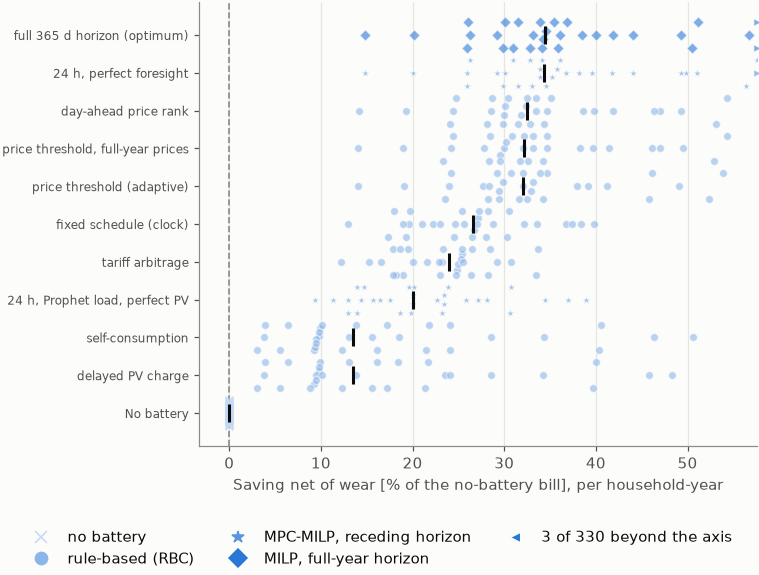

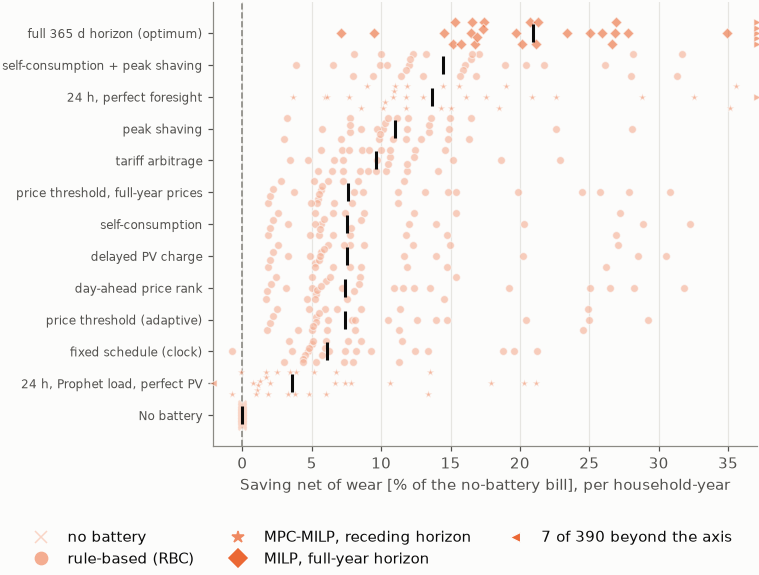

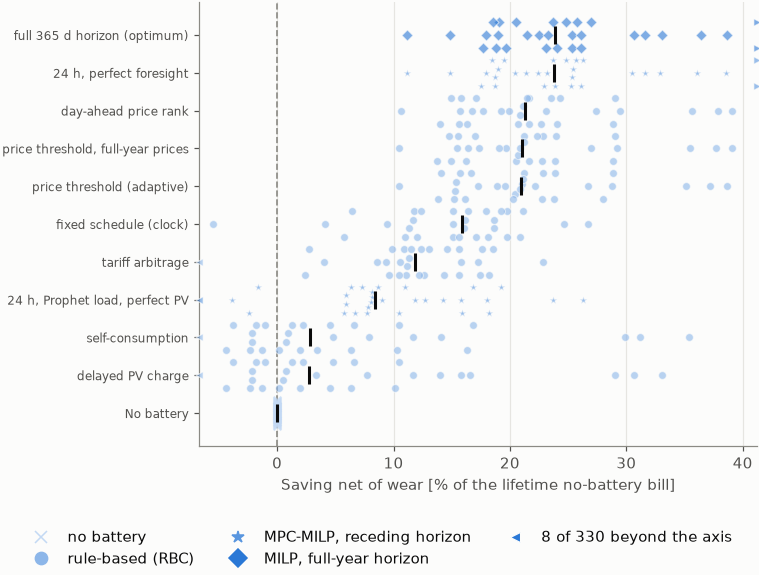

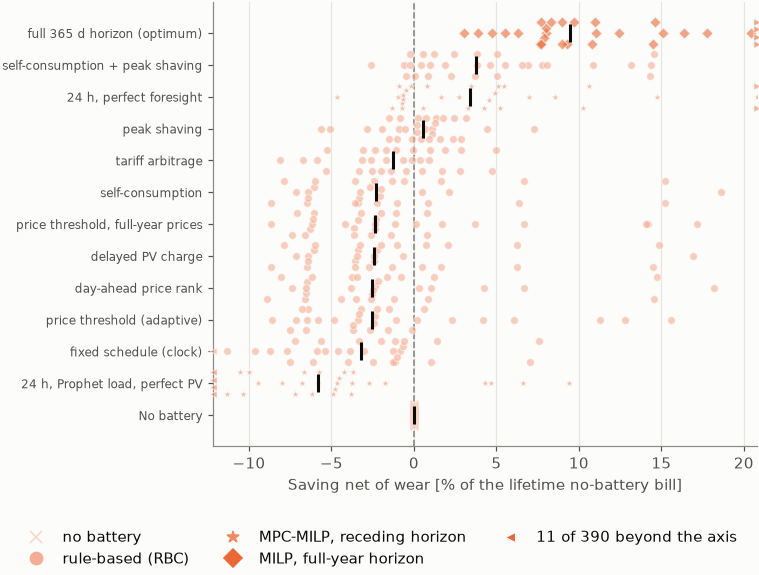

In [7]:
### Every controller on the reference arm: one dot per household, the bar is the median
# The "comparison of all" figure, one per tariff and per view -- the tariffs
# reward different behaviour, so the winner is not assumed to be the same on
# both, and one year is not a pack life.
#
# DRAWN ON `saving_total_pct` -- bill, standing charge and wear -- because that
# is the quantity the whole-period solve minimises and therefore the only one it
# bounds (section 3). On the energy bill alone the optimum is not a ceiling, and
# the price rules that pass it do so by spending 12 % of the bill on pack life
# against the optimum's 6 %.
from matplotlib.lines import Line2D


for view in VIEWS:
    _col = "saving_total_pct" if view["key"] == "annual" else "lifetime_saving_pct"
    for tariff, arm in REFERENCE_ARM.items():
        if arm not in set(long["arm"]):
            continue
        # The wear-price MILP (the ablation) joins its twin's panel under `<name>*`: it is
        # the same controller under an objective with one term removed, so it
        # belongs on the same axis and nowhere else.
        sub, stars = with_wearprice(long, arm)
        order = [c for c in hs.controller_columns(df_all) if c in set(sub["controller"])]
        order += [c for c in stars if c in set(sub["controller"])]
        med = (sub[sub["controller"].isin(order)]
               .groupby("controller")[_col].median())
        # SORTED BY THE MEDIAN, not in roster order -- this is a ranking.
        # `no_battery` is pinned to the bottom: it is the zero the others are
        # measured against, not a competitor with a score of 0.
        ctrls = [c for c in med.drop(index="no_battery", errors="ignore")
                 .sort_values(ascending=False).index]
        if "no_battery" in set(sub["controller"]):
            ctrls.append("no_battery")
        ypos = np.arange(len(ctrls))[::-1]

        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.80))
        _win = clip_window(
            sub.loc[sub["controller"].isin(ctrls), _col].dropna().to_numpy(),
            [med.get(c, np.nan) for c in ctrls])
        _out = 0
        for y, c in zip(ypos, ctrls):
            vals = sub.loc[sub["controller"] == c, _col].dropna().to_numpy()
            _halo = {} if ctrl_marker(c) in ("x", "+", "|", "_") else \
                {"edgecolor": SURFACE, "lw": 0.7}
            # The star rows are drawn hollow: same hue, same shape, same family
            # -- one term removed from the objective, and a reader must not be
            # able to mistake the two for one controller measured twice.
            if is_wearprice(c):
                _halo = {"edgecolor": ctrl_color(tariff, c), "lw": 1.0}
            _face = SURFACE if is_wearprice(c) else ctrl_color(tariff, c)
            _alpha = 0.95 if is_wearprice(c) else 0.6
            _keep = vals if _win is None else \
                vals[(vals >= _win[0]) & (vals <= _win[1])]
            ax.scatter(_keep, y + beeswarm(_keep), s=26,
                       marker=ctrl_marker(c), color=_face,
                       alpha=_alpha, zorder=3, **_halo)
            # Off the edge, on the edge: a caret at the boundary, one per
            # household, spread by the same beeswarm so a pile of them reads as
            # a pile. `clip_on=False` is what lets the glyph sit ON the spine
            # rather than half inside it.
            if _win is not None:
                for _edge, _sel, _mk in ((_win[0], vals < _win[0], "<"),
                                         (_win[1], vals > _win[1], ">")):
                    _n = int(_sel.sum())
                    if not _n:
                        continue
                    _out += _n
                    _at = np.full(_n, _edge)
                    ax.scatter(_at, y + beeswarm(_at), s=22, marker=_mk,
                               color=_face, alpha=_alpha, zorder=5,
                               clip_on=False, **_halo)
            # The median is taken over EVERY household, clipped or not -- the
            # window changes what is drawn, never what is counted.
            if len(vals):
                ax.scatter([np.median(vals)], [y], s=150, marker="|", color=INK,
                           lw=2.0, zorder=4)
        ax.axvline(0, color=MUTED, lw=1.1, ls="--")
        if _win is not None:
            ax.set_xlim(*_win)
        ax.set_yticks(ypos, [tick_label(c) for c in ctrls])
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", visible=False)
        # The lifetime label names its denominator rather than appending the
        # view's qualifier: an axes xlabel is centred on the AXES, which thirteen
        # rows of tick labels push well right of the figure's centre, so a long
        # label runs off the right edge of the exported box.
        finish(ax, xlabel=(f"Saving net of wear [{PCT_OF_BILL}], {view['per']}"
                           if view["key"] == "annual" else
                           f"Saving net of wear [{PCT_OF_LIFETIME_BILL}]"))

        _fams = [f for f in FAMILY_LABEL if any(FAMILY.get(c) == f for c in ctrls)]
        keys = [Line2D([], [], ls="", marker=FAMILY_MARKER[f], ms=8,
                       color=pf.mix(TARIFF_COLOR[tariff], "#ffffff",
                                    FAMILY_SHADE[f]),
                       markeredgecolor=pf.mix(TARIFF_COLOR[tariff], "#ffffff",
                                              FAMILY_SHADE[f]),
                       label=FAMILY_LABEL[f]) for f in _fams]
        if stars:
            keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                               markeredgecolor=ctrl_color(tariff, "milp_full"),
                               markeredgewidth=1.0,
                               label="* same MILP, per-cycle wear price in its objective"))
        # Every glyph in the image is defined in the image. The count is the
        # honest half: "clipped" without a number is a figure hiding its tail.
        if _out:
            keys.append(Line2D([], [], ls="", marker="<", ms=7,
                               color=ctrl_color(tariff, "milp_full"),
                               markeredgecolor=SURFACE, markeredgewidth=0.7,
                               label=f"{_out} of {len(sub)} beyond the axis"))
        # WHY THE TWO PANELS HAVE DIFFERENT ROWS, in the image's own caption. AU
        # carries eleven controllers and SI thirteen: the two peak-shaving rules
        # run on SI only, because Ausgrid EA025 as modelled has no capacity
        # charge for them to earn against and on AU they could only spend
        # round-trip losses. Without this a reader assumes they were dropped.
        _roster = ("; the two peak-shaving rules run on SI only -- AU as "
                   "modelled carries no capacity charge to shave"
                   if tariff == "SI" else
                   "; SI carries two peak-shaving rules that AU has no capacity "
                   "charge to earn from")
        pf.chart_frame(
            fig,
            f"Every controller on {tariff}, {SAMPLE}. Saving net of the cycles "
            f"it spends, as a share of the same household's no-battery bill, "
            f"over {view['note']} -- the quantity the whole-period solve "
            f"minimises and the only one it bounds{_roster}",
            handles=keys, ncol=min(len(keys), 3))
        pf.show(fig, f"controller_ranking_{tariff.lower()}{view['suffix']}",
                layout="frame")

  annual    AU: 1 of 5 tied with the best; SI: 1 of 5 tied with the best


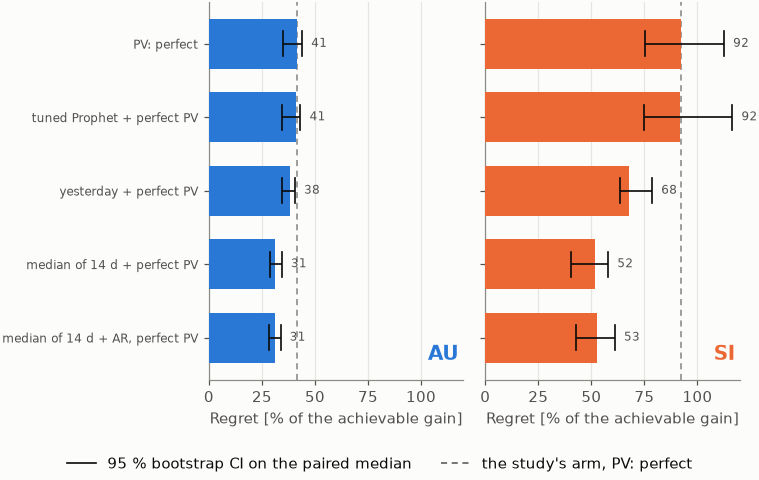

  _lifetime AU: 1 of 5 tied with the best; SI: 1 of 5 tied with the best


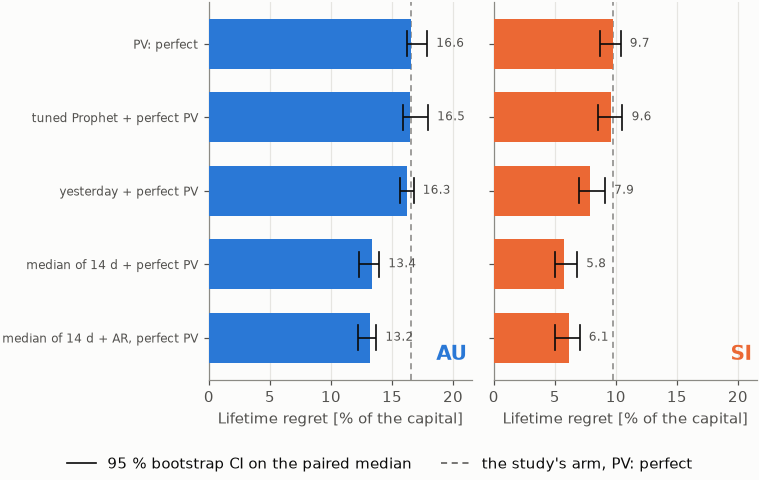

In [8]:
### What each forecast is worth: regret against perfect foresight
from matplotlib.lines import Line2D
from scipy import stats as st

# WHICH ARM SHOWS ME WHICH FORECAST. Rows are selected BY ARM, not by
# `forecaster_kind`: `AU_H24_leaked` carries kind == "prophet" exactly like
# `AU_H24`, so grouping by kind quietly averaged the current-interval look-ahead
# into Prophet's bar and flattered it by about 30 EUR. `hs.forecast_arms` reads
# the arm definitions and excludes it -- and also the `*_wearprice` arms, which
# carry no `forecaster_kind` either and would otherwise answer "which arm shows
# me Prophet?" with whichever of the two the roster order reached first.
ARM_FOR = {t: ps.forecast_arms(TRACK, t) for t in sorted(set(df_all["tariff"]))}

# The study's OWN forecaster, marked on every panel so each other method reads
# as better or worse than the arm the paper is about. Named rather than
# positional: the rows are reordered below and an index would silently move.
# Derived from the track: on the perfect-PV track the arm the notebook is
# about is `pvtruth`, not `prophet`, and a hardcoded "prophet" marks an arm
# that notebook does not even carry.
STUDY_KIND = ps.study_kind(TRACK)

def _regret_series(long, df_all, tariff, kind, denom, arm_for):
    """The PER-HOUSEHOLD regret for one (tariff, kind), as a Series.

    The SAMPLE, not its median. The median of the per-household DIFFERENCES is
    the right statistic -- a difference of two medians understates Prophet's
    regret by a third on SI -- but a median alone cannot be given an interval or
    tested, and returning the sample is what lets the figure do both.

    `denom` names what the share is OF: "gain" is what perfect foresight wins on
    that household, "capex" is the installed capital. Both are unit-free, so
    either puts AU and SI on one axis.
    """
    arm = arm_for[tariff][kind]
    s = df_all[df_all["arm"] == arm].set_index("dataset")
    gap = s["cost_prophet"] - s["cost_oracle"]
    if denom == "gain":
        gain = s["cost_no_battery"] - s["cost_oracle"]
        # Guarded per household, before any statistic: a household the battery
        # wins nothing on has no share for a regret to be a fraction of, and
        # dividing anyway produces a large number with an arbitrary sign.
        return (100.0 * gap.where(gain > 1e-9) / gain.where(gain > 1e-9)).dropna()
    # THE LIFETIME VIEW DIVIDES BY THE CAPITAL, and the choice is forced. A share
    # of the GAIN is invariant under discounting -- `pv_factor` multiplies the
    # regret and the gain alike and cancels -- so a lifetime share of the gain is
    # the annual panel again under a longer axis label.
    e = (long[(long["arm"] == arm) & (long["controller"] == "prophet")]
         .set_index("dataset")[["pv_factor", "capex"]].reindex(s.index))
    cap = e["capex"].where(e["capex"] > 1e-9)
    return (100.0 * gap * e["pv_factor"] / cap).dropna()
# What each forecast throws away, and how firmly that is known. Fourteen sorted
# paired medians say nothing on their own about whether 35 and 36 differ, so two
# things carry that:
#
#   the interval   a percentile bootstrap of the paired median over the same
#                  30 households, drawn as a whisker on the bar end. The
#                  statistic is a median of ratios on n = 30 with a few
#                  households far out, so it is resampled rather than handed a
#                  normal approximation.
#   the test       every method against the BEST on that panel, Wilcoxon on the
#                  per-household differences, Holm-adjusted over the thirteen
#                  comparisons -- at thirteen tries an unadjusted 5 % finds a
#                  winner by chance about half the time. A method that does not
#                  separate from the best is drawn hollow, so "these are tied"
#                  is a thing the image can say.
have = set(df_all["arm"])
kinds = [k for k in hs.FORECAST_KIND_LABELS
         if all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(kinds) <= 1):
    PVF = float(long["pv_factor"].dropna().median())

    for view, denom in (("", "gain"), ("_lifetime", "capex")):
        series = {t: {k: _regret_series(long, df_all, t, k, denom, ARM_FOR)
                      for k in kinds} for t in ARM_FOR}
        vals = {t: [float(series[t][k].median()) for k in kinds] for t in ARM_FOR}

        # SORTED BY REGRET, on ONE tariff's ordering, and said so in the caption.
        # Sorting each panel separately would be worse -- the rows would stop
        # lining up and the rank disagreement between the tariffs, which is a
        # result, would become invisible.
        by = sorted(ARM_FOR)[0]
        rank = np.argsort([-v if v == v else -np.inf for v in vals[by]])
        ks = [kinds[i] for i in rank]
        y = np.arange(len(ks))[::-1]

        fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.68),
                                 sharey=True, sharex=True)
        axes = np.atleast_1d(axes)
        fin = [x for x in sum(vals.values(), []) if x == x]
        n_tied = {}
        for ax, tariff in zip(axes, sorted(ARM_FOR)):
            v = [vals[tariff][kinds.index(k)] for k in ks]
            best = ks[int(np.nanargmin(v))]
            # HOLM OVER THE PANEL'S OWN COMPARISONS. Every method against the
            # best one, paired per household; the family is this panel.
            others = [k for k in ks if k != best]
            raw = []
            for k in others:
                pair = pd.concat([series[tariff][k], series[tariff][best]],
                                 axis=1, keys=["k", "b"]).dropna()
                d = (pair["k"] - pair["b"])
                nz = d[d != 0]
                raw.append(st.wilcoxon(nz).pvalue if len(nz) >= 6 else np.nan)
            adj = dict(zip(others, fs.holm(raw)))
            tied = {k for k in others if not (adj[k] == adj[k] and adj[k] < 0.05)}
            n_tied[tariff] = len(tied) + 1

            for yi, k, vi in zip(y, ks, v):
                is_best = k == best
                solid = is_best or k not in tied
                ax.barh(yi, vi, height=0.68,
                        color=fs.TARIFF_COLOR[tariff] if solid else SURFACE,
                        edgecolor=fs.TARIFF_COLOR[tariff],
                        lw=0.0 if solid else 1.1, zorder=3)
                lo, hi = fs.boot_ci(series[tariff][k].to_numpy())
                if lo == lo:
                    ax.plot([lo, hi], [yi, yi], color=INK, lw=1.1, zorder=5,
                            solid_capstyle="butt")
                    for e in (lo, hi):
                        ax.plot([e, e], [yi - 0.17, yi + 0.17], color=INK,
                                lw=1.1, zorder=5)
                if vi == vi:
                    # OUTSIDE THE INTERVAL, not outside the bar: the whisker runs
                    # past the bar end and a label placed on the bar end lands on
                    # it.
                    end = hi if hi == hi and vi >= 0 else vi
                    end = lo if lo == lo and vi < 0 else end
                    ax.annotate(("{:.0f}" if denom == "gain" else "{:.1f}")
                                .format(vi), xy=(end, yi),
                                xytext=(6 if vi >= 0 else -6, 0),
                                textcoords="offset points",
                                ha="left" if vi >= 0 else "right", va="center",
                                color=INK_2, fontsize=8, zorder=6)
            # THE STUDY'S OWN FORECASTER, as a rule the other bars are read
            # against. Behind the bars, so it never hides one.
            if STUDY_KIND in ks:
                ref = vals[tariff][kinds.index(STUDY_KIND)]
                if ref == ref:
                    ax.axvline(ref, color=INK_2, lw=1.0, ls=(0, (4, 3)),
                               zorder=1, alpha=0.7)
            if fin:
                ax.set_xlim(min(0.0, min(fin) * 1.30), max(0.0, max(fin) * 1.30))
            if min(fin, default=0.0) < 0:
                ax.axvline(0, color=INK, lw=1.0, zorder=4)
            ax.grid(axis="y", visible=False)
            # NOT finish(title=...): `titles=False` lifts axes titles out of the
            # image and into the caption, which is right for a figure title and
            # wrong for panel identity.
            ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                        ha="right", va="bottom", color=fs.TARIFF_COLOR[tariff],
                        fontsize=13, fontweight="bold")
        axes[0].set_yticks(y, [hs.forecast_kind_label(k) for k in ks])
        axes[0].tick_params(axis="y", labelsize=8)
        # PER AXES, NOT `fig.supxlabel`. This figure carries a key, so
        # `chart_frame` reserves a bottom band -- and a supxlabel is a figure
        # artist that tight_layout does not move, so it lands on the legend row.
        # An axes xlabel is inside the rect and gets laid out.
        for ax in axes:
            finish(ax, xlabel=(f"Regret [{fs.PCT_OF_GAIN_SHORT}]" if denom == "gain"
                               else f"Lifetime regret [{fs.PCT_OF_CAPEX}]"))

        keys = [Line2D([], [], color=INK, lw=1.1,
                       label="95 % bootstrap CI on the paired median"),
                Line2D([], [], color=INK_2, lw=1.0, ls=(0, (4, 3)),
                       label=f"the study's arm, "
                             f"{hs.forecast_kind_label(STUDY_KIND)}")]
        # THE HOLLOW KEY ONLY WHEN THERE IS A HOLLOW BAR. On this sweep all
        # thirteen separate from their panel's best, so the key would name a
        # mark that is nowhere in the image. The count goes in the caption
        # either way, which is where the result belongs.
        if max(n_tied.values()) > 1:
            keys.insert(0, Line2D([], [], marker="s", ls="", ms=9, color=SURFACE,
                                  markeredgecolor=fs.TARIFF_COLOR[sorted(ARM_FOR)[0]],
                                  markeredgewidth=1.1,
                                  label="not separable from the panel's best"))
        pf.chart_frame(
            fig,
            (f"What each forecast throws away, as a share of the ACHIEVABLE "
             f"gain -- what perfect foresight wins on that same household. One "
             f"unit, one axis, so the two tariffs can be compared directly"
             if denom == "gain" else
             f"What each forecast costs over the pack's {PVF:.1f}-year "
             f"discounted life, as a share of what the pack cost. Not the same "
             f"statement as the annual panel: a share of the GAIN cancels the "
             f"discount factor out of itself and would reproduce it exactly"),
            subtitle=f"Paired median over {SAMPLE}, with a percentile bootstrap "
                     f"interval; rows sorted by {sorted(ARM_FOR)[0]} regret, so "
                     f"the panels line up and a rank disagreement stays visible. "
                     f"Every row was tested against its panel's best with a "
                     f"Wilcoxon on the per-household differences, Holm-adjusted "
                     f"over the {len(ks) - 1} comparisons; a row that does not "
                     f"separate is drawn hollow. "
                     + ("None does here -- all "
                        f"{len(ks) - 1} separate on both tariffs, so the "
                        f"ordering is real and not an artefact of taking a "
                        f"median."
                        if max(n_tied.values()) == 1 else
                        "; ".join(f"{t}: {n_tied[t] - 1} of {len(ks) - 1} do not"
                                  for t in sorted(ARM_FOR))),
            handles=keys, ncol=2)
        print(f"  {view or 'annual':9s} "
              + "; ".join(f"{t}: {n_tied[t]} of {len(ks)} tied with the best"
                          for t in sorted(ARM_FOR)))
        pf.show(fig, f"forecast_channel_regret{view}", layout="frame")
else:
        print(f"Only the {kinds} arm has run; this figure needs the others.")

In [9]:
### Which load forecast is best, before spending a MILP on it -- READ FROM THE SCREEN
# THIS NOTEBOOK DOES NOT SCORE FORECASTS. `forecast_benchmark.csv` is keyed on
# the kind and the household and knows nothing about a tariff or an arm, so all
# three notebooks would rescore it into three identical files at one path -- and
# two of them at once would write a truncated one. `CODE_PV_FORECAST.ipynb` owns
# it; this reads it.
#
# It is read at all because the figure below needs a forecast's ERROR beside its
# regret, and the load models in this notebook's arms are exactly the ones that
# screen scored: `median14_pvtruth` is `median14` on the consumption channel with
# a channel replaced by the truth, and `ps.load_kind` is what says so.
#
# The generation rows are not dropped from the table -- they are the reason these
# arms exist, and "Prophet scores -0.17 on the roof against yesterday's 0.00" is
# the measurement the perfect-PV bound was built to price. They are simply not
# what this notebook's arms consumed.
bench = ps.read_screen("benchmark")

print(hs.benchmark_ranking(bench).round(3).to_string())
print(f"\nnMAE is the day-ahead mean absolute error over the mean actual; skill is "
      f"1 - MAE/MAE_yesterday.")
print(f"Medians over {bench['dataset'].nunique()} households.")
print(f"  scored: {hs.provenance(bench, n_sim=N_SIM)}")

# WHICH OF THESE ROWS THIS NOTEBOOK'S ARMS ACTUALLY RUN, and on which channel.
# Without this the table above reads as the notebook's own roster, and it is not:
# it is every kind the screen scored, of which these arms use five load models
# and no generation model at all.
_mine = {k: ps.load_kind(k) for k in
         sorted({k for t in ARM_FOR for k in ARM_FOR[t]},
                key=list(hs.FORECAST_KIND_LABELS).index)}
print(f"\nThe {len(_mine)} arms in this notebook, and the row above each one is scored by:")
for _k, _lk in _mine.items():
    print(f"   {hs.forecast_kind_label(_k):34s} load = {_lk:14s} "
          f"roof = truth (no error to score)")


                     nmae                  skill             households           
channel       consumption generation consumption generation consumption generation
kind                                                                              
persistence         0.577      0.417       0.000      0.000        30.0       30.0
weekly              0.595      0.479      -0.066     -0.148        30.0       30.0
daytype             0.585      0.437      -0.022     -0.055        30.0       30.0
mean3               0.515      0.391       0.113      0.055        30.0       30.0
mean7               0.486      0.381       0.148      0.086        30.0       30.0
median7             0.449      0.388       0.203      0.072        30.0       30.0
median14            0.450      0.373       0.218      0.112        30.0       30.0
prophet             0.631      0.488      -0.102     -0.171        30.0       30.0
prophet_tuned       0.615      0.496      -0.097     -0.185        30.0       30.0
hbd 

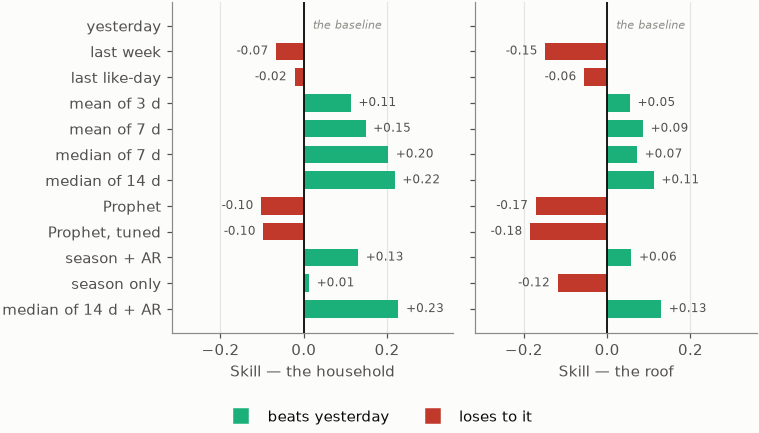

In [10]:
### Figure: what each trivial method buys against copying yesterday
# TWO PANELS, not two colours in one: the channels are different questions
# ("can you predict this roof" / "can you predict this household"), and the
# palette's two remaining hues do not separate well enough under protanopia to
# carry that on colour alone. Faceting makes the comparison within a channel --
# which is the comparison anyone reads this figure for -- the near one.
#
# Colour encodes SIGN, and only sign. Green/red rather than green/orange:
# orange is the SI tariff on every other figure here, and a reader who has
# learnt that cannot be asked to unlearn it. The bar's direction from zero says
# the same thing, so colour is never load-bearing on its own.
med = (bench.groupby(["kind", "channel"], observed=True)["skill_vs_naive"]
            .median().unstack())
med = med.loc[[k for k in hs.FORECAST_KIND_LABELS if k in med.index]]

# One x scale across both panels. They are small multiples of the same
# measurement, so "is the roof harder than the household" has to be readable off
# the bar lengths; two scales would make every bar look the same size.
span = med.to_numpy()
lo, hi = min(span.min(), 0.0), max(span.max(), 0.0)
pad = 0.32 * (hi - lo)                      # room for the value labels

# Twelve rows need about 0.62 of ratio: below that the tick labels and value
# annotations stop being legible at IEEE single-column width, which is what this
# figure is for.
fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.62),
                         sharey=True, sharex=True)
for ax, channel, what in zip(axes, ("consumption", "generation"),
                             ("the household", "the roof")):
    vals = med[channel].to_numpy()
    y = np.arange(len(med))[::-1]           # best-known first, reading downward
    # `yesterday` IS the denominator -- its skill against itself is 0 by
    # construction, not by measurement. Drawn as a bar it was a zero-length bar
    # labelled "+0.00", which is what a missing result looks like. It is the
    # baseline, so it is drawn as the baseline: the zero rule, named on the axis,
    # with no bar and no value.
    _is_base = np.array([k == "persistence" for k in med.index])
    # `v > 0` painted an exact zero and a NaN as "loses", which is a claim about
    # neither. Sign is three-valued and the colours say so.
    _col = [SURFACE if b else (BEATS if v > 0 else LOSES)
            for v, b in zip(vals, _is_base)]
    ax.barh(y, np.where(_is_base, 0.0, vals), height=0.68, color=_col)
    ax.axvline(0, color=INK, lw=1.2, zorder=3)
    for yi, v, b in zip(y, vals, _is_base):
        if b:
            ax.annotate("the baseline", xy=(0, yi), xytext=(6, 0),
                        textcoords="offset points", ha="left", va="center",
                        color=MUTED, fontsize=7.5, style="italic")
            continue
        ax.annotate(f"{v:+.2f}", xy=(v, yi),
                    xytext=(5 if v >= 0 else -5, 0), textcoords="offset points",
                    ha="left" if v >= 0 else "right", va="center",
                    color=INK_2, fontsize=8)
    ax.set_yticks(y, [hs.FORECAST_KIND_LABELS.get(k, k).split(": ")[-1]
                      for k in med.index])
    ax.set_xlim(lo - pad, hi + pad)
    ax.grid(axis="y", visible=False)
    # Panel identity goes in the X LABEL, not a title and not an in-axes mark.
    # `pf.use(titles=False)` lifts axes titles into the export's caption, which
    # would leave two unlabelled panels; and every corner of these axes is
    # occupied by either a bar or its value label, so an annotation collides
    # with something at some data. The xlabel has reserved space of its own, and
    # is kept short: these are half-width panels whose labels are centred under
    # axes that meet in the middle, so at full length they read as one run-on
    # line. What skill is measured against is in the caption, said once.
    finish(ax, xlabel=f"Skill \u2014 {what}")

# Skill is a RATIO and carries no unit, so what it is a ratio of is said in the
# CAPTION. Not in the x labels -- the half-width panels already run edge to edge
# and a scale appended to both collides in the middle -- and not as a legend
# title, since `pf.key_legend(..., where="below")` anchors to `axes[0]` and a
# title wider than the legend box starts outside the figure's left edge.
# `pf.use(titles=False)` sends the title into the export's SOURCE.md for the
# article to carry, which is where an IEEE figure's definitions belong; the keys
# keep the sign, which is the part that has to be read off the image.
#
# `chart_frame` measures the legend band in inches and lays the axes out in what
# is left, so the keys are centred on the FIGURE and nothing is squeezed. It has
# to be paired with `layout="frame"`, or `show` runs tight_layout again.
pf.chart_frame(
    fig,
    "What each trivial method buys against copying yesterday, by channel. "
    "skill = 1 \u2212 MAE / MAE_yesterday: 0 is yesterday, 1 is a forecast with "
    "no error; green beats yesterday, red loses to it",
    handles=[plt.Line2D([], [], marker="s", ls="", ms=9, color=c, label=lab)
             for c, lab in ((BEATS, "beats yesterday"), (LOSES, "loses to it"))],
    ncol=2)
pf.show(fig, "forecast_method_skill", layout="frame")

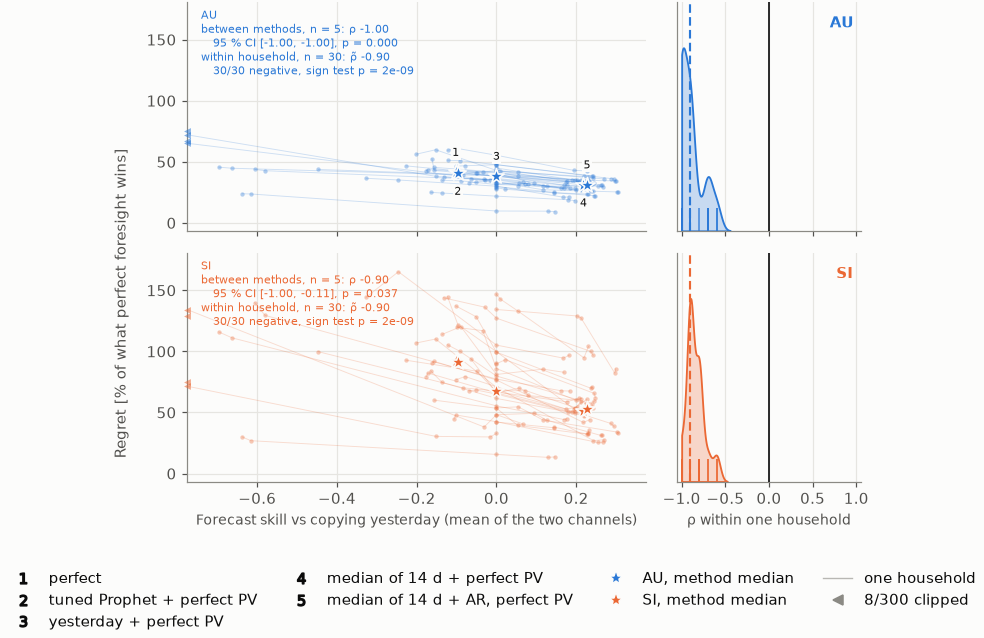

In [11]:
# Per-tariff statistics, read back by the caption below instead of typed
# into it: a typed "28 of 30" outlived the dispatch it described.
_svr = {}
### Does a better forecast buy a smaller regret?
from matplotlib.lines import Line2D
from scipy import stats as st
import seaborn as sns

# TWO STATISTICS, and the paired one is the stronger. Correlating skill against
# regret WITHIN each household, across the seven methods, then asking whether
# those thirty correlations sit below zero (on the wear-free dispatch: median
# -0.86, negative on 29 of 30 households on AU, sign test p = 6e-8; SI 30 of 30).
# The between-method reading --
# seven method medians against seven -- is also printed, because it is a real
# statement about the METHODS, but seven points support little and its interval
# says so.
#
# LABELS ON THE TOP PANEL ONLY. A method's skill does not depend on the tariff
# it is dispatched against, so the seven medians sit at the SAME x in both
# panels and a second copy of the names would say nothing the first did not --
# while costing, on the SI panel, three collisions that no offset ladder fixes.
have = set(df_all["arm"])

skill = (bench.pivot_table(index=["dataset", "kind"], columns="channel",
                           values="skill_vs_naive", observed=True)
         .assign(both=lambda d: d[["consumption", "generation"]].mean(axis=1))
         [SKILL_CHANNEL])
# SCORED BY THE LOAD MODEL INSIDE THE KIND. `forecast_benchmark.csv` scores
# forecasters, and `median14_pvtruth` is not one -- it is `median14` with a
# channel replaced by the truth, and the benchmark has never heard of it. On the
# forecast track `ps.load_kind` is the identity and this changes nothing; on the
# perfect track it is what lets the figure be drawn at all, and `SKILL_CHANNEL`
# above keeps it honest by reading only the channel that was actually forecast.
JOIN = [k for k in hs.FORECAST_KIND_LABELS
        if ps.load_kind(k) in set(skill.index.get_level_values("kind"))
        and all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]
if not (len(JOIN) <= 2):
    rows = []
    for t in ARM_FOR:
        for k in JOIN:
            r = (long[(long["arm"] == ARM_FOR[t][k])
                      & (long["controller"] == "prophet")]
                 .set_index("dataset")["regret_pct_of_gain"])
            s = skill.xs(ps.load_kind(k), level="kind")
            for hh in r.index:
                if hh in s.index:
                    rows.append({"tariff": t, "kind": k, "dataset": hh,
                                 "skill": float(s[hh]), "regret": float(r[hh])})
    D = pd.DataFrame(rows)

    # ONE HOUSEHOLD SETS THE SKILL AXIS otherwise: Ausgrid 81's consumption model
    # is 2.6x worse than copying yesterday and drags the pooled range to -1.02,
    # which squeezes every method median into the right quarter of the panel.
    # `clip_window` clips the axis, draws what is outside ON the boundary as a
    # caret and names the count in the key. Nothing is dropped from either
    # statistic: both are taken over every point.
    win = fs.clip_window(D["skill"].to_numpy(),
                         D.groupby(["tariff", "kind"], observed=True)["skill"]
                         .median().to_numpy(), q=0.03, pad=0.08)
    n_out = int(((D["skill"] < win[0]) | (D["skill"] > win[1])).sum())
    # Headroom at the TOP for the label ladder the AU panel carries, and a
    # little at the bottom so the lowest household is not drawn on the spine.
    ylim = fs.clip_window(D["regret"].to_numpy(), [], q=0.0, pad=0.10)

    fig, axes = plt.subplots(len(ARM_FOR), 2, figsize=pf.figsize(ratio=0.88),
                             width_ratios=[2.5, 1.0], sharex="col")
    ax_main, ax_rho = axes[:, 0], axes[:, 1]

    for i, (ax, axr, tariff) in enumerate(zip(ax_main, ax_rho, sorted(ARM_FOR))):
        col = fs.TARIFF_COLOR[tariff]
        s = D[D["tariff"] == tariff]
        # THE PAIRING, DRAWN. One faint line per household joining its seven
        # methods in skill order. The claim is about what happens WITHIN a
        # household when it is handed a better forecast, so the household is the
        # object the figure has to show; a cloud of 210 loose dots shows the
        # between-household spread instead, which is the nuisance here.
        for _hh, h in s.groupby("dataset"):
            h = h.sort_values("skill")
            ax.plot(h["skill"].clip(*win), h["regret"], color=col, lw=0.6,
                    alpha=0.22, zorder=2)
        ins = (s["skill"] >= win[0]) & (s["skill"] <= win[1])
        ax.scatter(s.loc[ins, "skill"], s.loc[ins, "regret"], s=8, color=col,
                   alpha=0.35, lw=0, zorder=3)
        for edge, sel, mk in ((win[0], s["skill"] < win[0], "<"),
                              (win[1], s["skill"] > win[1], ">")):
            if int(sel.sum()):
                ax.scatter(np.full(int(sel.sum()), edge), s.loc[sel, "regret"],
                           s=20, marker=mk, color=col, alpha=0.55, lw=0,
                           zorder=4, clip_on=False)

        med = s.groupby("kind", observed=True).median(numeric_only=True)
        med = med.loc[[k for k in JOIN if k in med.index]].dropna()
        ax.scatter(med["skill"], med["regret"], s=110,
                   marker=fs.FAMILY_MARKER["MPC"], color=col,
                   edgecolor=SURFACE, lw=1.1, zorder=6)
        if i == 0:
            # NUMBERED, AND THE NAMES GO IN THE KEY. The seven medians cluster
            # in the right half of an axis the outliers stretch, on a panel
            # ~160 px tall, so no in-panel placement of seven names avoids
            # collisions. A digit is one character, cannot collide with its
            # neighbour, and costs the reader one lookup -- the honest trade
            # when the names do not fit.
            # ABOVE AND BELOW BY PARITY, because two of the seven pairs are
            # near-coincident in x -- `prophet` and `prophet_tuned` differ by
            # 0.01 skill, `median14` and `hbd_median14` by 0.013 -- and two
            # badges on the same side of near-identical points are one glyph.
            for badge, (k, r) in enumerate(med.sort_values("skill").iterrows(), 1):
                up = badge % 2 == 1
                ax.annotate(str(badge), xy=(r["skill"], r["regret"]),
                            xytext=(0, 9 if up else -9),
                            textcoords="offset points", ha="center",
                            va="bottom" if up else "top", fontsize=7, color=INK,
                            zorder=8,
                            bbox=dict(facecolor=SURFACE, edgecolor="none",
                                      pad=0.9))

        # THE TWO STATISTICS, both named: they are two different questions, and
        # the paired one is the claim.
        rho_b, p_b, lo_b, hi_b, n_b = fs.spearman_ci(med["skill"], med["regret"])
        rr = (s.groupby("dataset")
              .apply(lambda h: st.spearmanr(h["skill"], h["regret"]).statistic)
              .dropna())
        neg = int((rr < 0).sum())
        p_s = st.binomtest(neg, len(rr), 0.5).pvalue
        _svr[tariff] = dict(neg=neg, n=len(rr), rho_b=rho_b, p_b=p_b, n_b=n_b)
        ax.set_ylim(*ylim)
        fs.corner_block(
            ax,
            f"{tariff}\nbetween methods, n = {n_b}: ρ {rho_b:+.2f}\n"
            f"   95 % CI [{lo_b:+.2f}, {hi_b:+.2f}], p = {p_b:.3f}\n"
            f"within household, n = {len(rr)}: ρ̃ {rr.median():+.2f}\n"
            f"   {neg}/{len(rr)} negative, sign test p = {p_s:.0e}",
            col, s["regret"], lims=ylim, fontsize=7.5)
        finish(ax)

        # THE DISTRIBUTION THE STRONGER CLAIM RESTS ON, beside the scatter. One
        # rho per household, so a reader sees that the effect is not carried by
        # a few houses -- which a pooled correlation cannot show and a p-value
        # only asserts.
        sns.kdeplot(x=rr.to_numpy(), ax=axr, color=col, fill=True, alpha=0.25,
                    lw=1.2, bw_adjust=0.8, clip=(-1, 1))
        sns.rugplot(x=rr.to_numpy(), ax=axr, color=col, height=0.10, lw=0.9,
                    alpha=0.85)
        axr.axvline(0, color=INK, lw=1.1, zorder=4)
        axr.axvline(float(rr.median()), color=col, lw=1.4, ls=(0, (4, 2)),
                    zorder=5)
        axr.set_xlim(-1.05, 1.05)
        axr.set_xticks([-1, -0.5, 0, 0.5, 1])
        axr.set_yticks([])
        axr.set_ylabel("")
        axr.grid(axis="y", visible=False)
        # TOP RIGHT, where this distribution never is: every rho worth drawing
        # sits at or below zero, so the right half of the panel is empty by
        # construction and a left-hand mark would print on the mode.
        axr.annotate(f"{tariff}", xy=(0.96, 0.94), xycoords="axes fraction",
                     ha="right", va="top", color=col, fontsize=10,
                     fontweight="bold")
        finish(axr)

    ax_main[0].set_xlim(*win)
    # SUPXLABEL, not one per axes: the two columns are different units and each
    # needs its own words, but an axes xlabel is centred on the AXES and the two
    # here are 2.5:1 in width, so the pair reads as one off-centre run-on line.
    # Two figure-level labels, each placed over its own column.
    fig.supylabel(f"Regret [{fs.PCT_OF_GAIN}]", color=INK_2, fontsize=10)
    ax_main[-1].set_xlabel("Forecast skill vs copying yesterday "
                           "(mean of the two channels)", color=INK_2, fontsize=9)
    ax_rho[-1].set_xlabel("ρ within one household", color=INK_2, fontsize=9)

    # THE NUMBERED KEY, ordered by skill exactly as the badges are, and built
    # from the same Series -- so a method added to the roster cannot appear on
    # the chart with no name beside it.
    badge_order = (D[D["tariff"] == sorted(ARM_FOR)[0]]
                   .groupby("kind", observed=True)["skill"].median()
                   .reindex(JOIN).dropna().sort_values().index)
    keys = [Line2D([], [], ls="", marker="$%d$" % (i + 1), ms=7, color=INK,
                   label=hs.forecast_kind_label(k).split(": ")[-1])
            for i, k in enumerate(badge_order)]
    keys += [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=10,
                    color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
                    label=f"{t}, method median") for t in sorted(ARM_FOR)]
    # SHORT KEYS. Ten of them at four columns is a row about 7.5 in wide on a
    # 7.16 in canvas, i.e. both ends outside the box.
    keys.append(Line2D([], [], color=MUTED, lw=0.9, alpha=0.6,
                       label="one household"))
    if n_out:
        keys.append(Line2D([], [], ls="", marker="<", ms=7, color=MUTED,
                           label=f"{n_out}/{len(D)} clipped"))
    _au = _svr["AU"]
    _svr_note = (f" and on AU it is n = {_au['n_b']} and does not clear 5 %"
                 if _au["p_b"] >= 0.05 else
                 f"; on AU it agrees here, n = {_au['n_b']}: ρ {_au['rho_b']:+.2f}, "
                 f"p = {_au['p_b']:.4f}")
    pf.chart_frame(
        fig,
        f"A better forecast does buy a smaller regret, and it is the PAIRED "
        f"test that says so: within a household, skill and regret are ranked "
        f"opposite on {_svr['AU']['neg']} of {_svr['AU']['n']} households on AU "
        f"and {_svr['SI']['neg']} of {_svr['SI']['n']} on SI",
        subtitle=f"{len(JOIN)} forecast methods over {SAMPLE}, one line per "
                 f"household. x: skill against copying yesterday, the mean of "
                 f"the two channels -- it does not depend on the tariff, so the "
                 f"medians sit at the same x in both panels and are "
                 f"numbered once, in skill order. "
                 f"y: the share of the achievable saving thrown away. The "
                 f"between-method ρ over the seven method medians is the weaker "
                 f"reading{_svr_note}; the "
                 f"right-hand panels are the per-household ρ that reading "
                 f"discards",
        handles=keys, ncol=4)
    pf.show(fig, "skill_vs_regret", layout="frame")
else:
        print(f"Only {JOIN} appear in both the benchmark and the arms; this "
              f"figure needs at least three.")

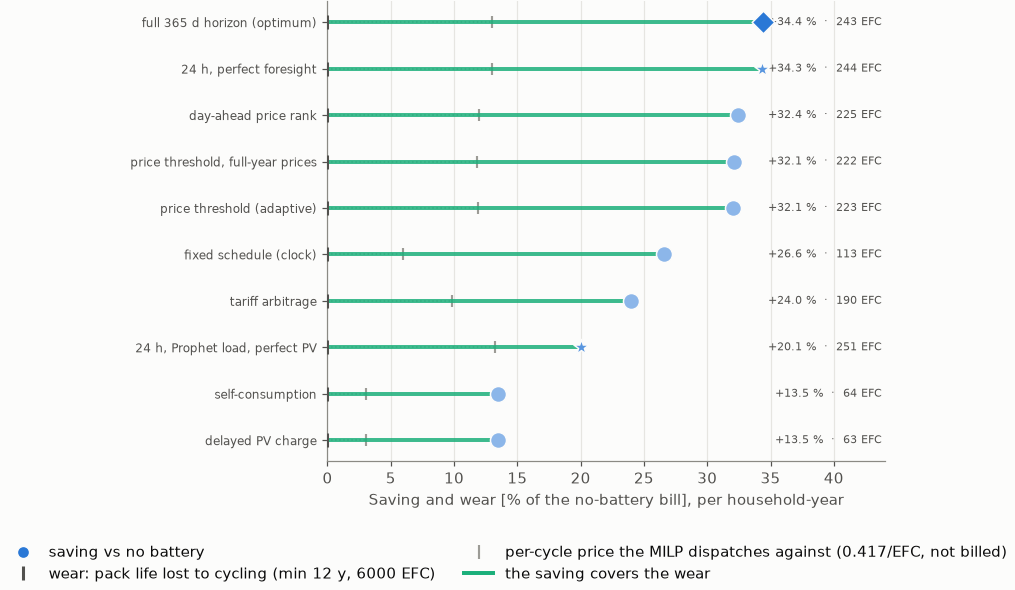

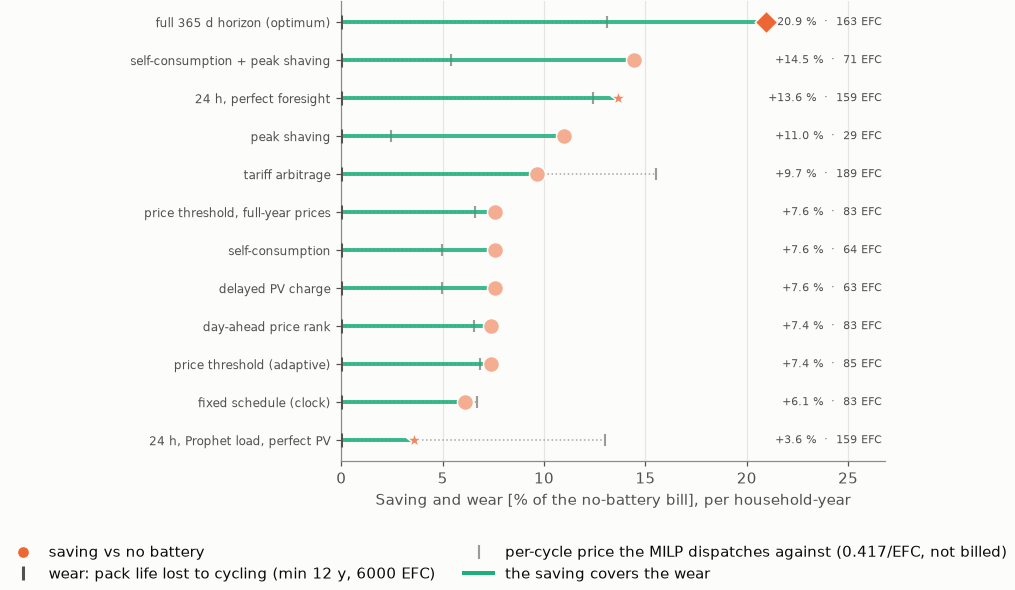

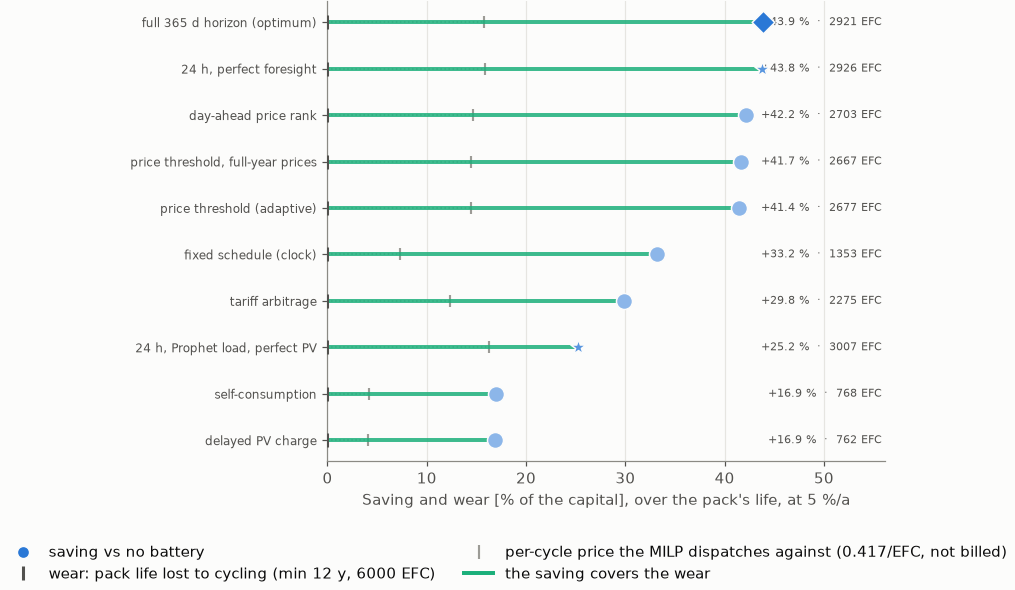

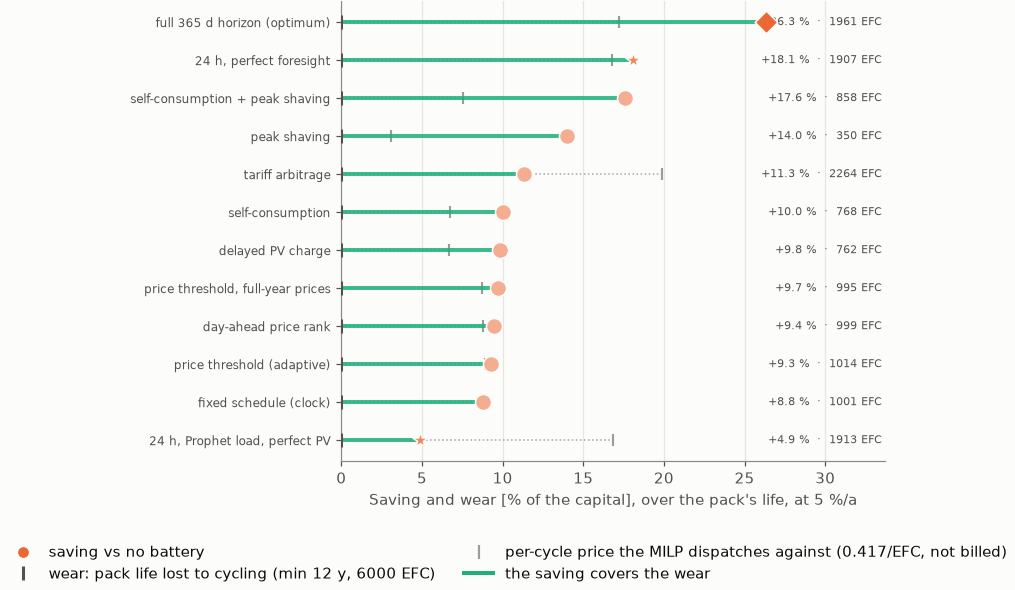

In [12]:
### What a saving costs in pack life: the year's saving against the year's wear
# One row per controller, name on the y axis where it always fits. The mark is
# the median household's OPERATING saving, the tick is that household's wear,
# and the bar between them is what is left over -- so "does this controller pay
# for the cycles it spends" is the direction of one bar, and the ranking is the
# order of the rows.
#
# ROWS RATHER THAN A SCATTER of efc against saving. Ten to thirteen controllers
# land in a small region of that plane -- `delayed_pv_charge` and
# `self_consumption` are 0.5 cycles and 0.02 EUR apart -- with names running to
# 54 characters, and no label placement on it is legible.
#
# BOTH AXES ARE SHARES, which is what lets AU and SI be read against each other
# at all. In money the two panels were 270 AUD and 45 EUR wide over different
# bills, so the only available reading was within a panel; as a share the
# sentence is one unit on both.
#
# TWO VIEWS, AND TWO DENOMINATORS. The annual view is the simulated year against
# the year's no-battery bill -- "this controller earns 21 % of the bill and
# spends 12 % of it on pack life". The lifetime view discounts both marks over
# each row's own service life and divides by the CAPITAL: "over its life it
# earns 61 % of what the pack cost and spends 28 % of it on wear".
#
# The denominator has to change with the view or there is no second figure: a
# discounted saving over a discounted bill cancels `pv_factor` out of numerator
# and denominator alike and returns the annual number under a lifetime axis
# label.
#
# COLOUR. Sign is green/red, NOT green/orange -- orange is the SI tariff on
# every other figure here, so on an SI panel it cannot also mean "over budget".
import Battery_Economics as be
from matplotlib.lines import Line2D

CAP_KWH = float(df_all["battery_cap"].median())

for view in VIEWS:
    for tariff, arm in REFERENCE_ARM.items():
        sub, stars = with_wearprice(long, arm)
        sub = sub[sub["controller"] != "no_battery"]
        if sub.empty or sub["efc"].isna().all():
            continue
        # TWO DENOMINATORS, one per view -- see the header. Against the capital
        # the lifetime view makes a new statement rather than restating the
        # annual one: "over its life this controller earns 61 % of what the pack
        # cost and spends 28 % of it on wear".
        if view["key"] == "annual":
            _pvf, _denom = 1.0, sub["baseline_cost_total"]
            _of = PCT_OF_BILL
        else:
            _pvf, _denom = sub["pv_factor"], sub["capex"]
            _of = PCT_OF_CAPEX
        work = sub.assign(
            _save=100.0 * (sub["saving_operating"] * _pvf) / _denom,
            _wear=100.0 * (sub["wear_eur"] * _pvf) / _denom,
            # The per-cycle price the MILP DISPATCHES against, on the same
            # scale -- reported, never billed. Drawn faint beside the real
            # wear so the gap between the two is visible.
            _shadow=100.0 * (sub["wear_shadow_eur"] * _pvf) / _denom,
            _net=100.0 * (sub["saving_annual_net"] * _pvf) / _denom,
            # Cycles over the same horizon: the year's EFC in the annual view,
            # the whole pack life's in the lifetime one.
            _efc=sub["efc"] * (1.0 if view["key"] == "annual"
                               else sub["service_life_y"]))
        med = (work.groupby("controller")
               .agg(saving=("_save", "median"), wear=("_wear", "median"),
                    shadow=("_shadow", "median"),
                    net=("_net", "median"), efc=("_efc", "median"),
                    binds=("life_binds_on_cycles", "mean"))
               .dropna().sort_values("net", ascending=False))
        ypos = np.arange(len(med))[::-1]          # best at the top

        # The rate the sweep ACCOUNTS wear at, read from the frame -- so a sweep
        # solved at another pack price moves this figure with it instead of
        # being drawn against a constant nobody re-ran. NOT the rate the MILP was
        # charged: the main arms dispatch at 0 and only the `*_wearprice` ablation
        # carries this rate. Drawn as the faint tick, reported and never billed.
        _slope = float(sub["wear_rate_accounted"].dropna().median())
        _slope_quote = (be.cycle_cost_eur_per_efc(CAP_KWH)
                        * hs.ARM_CURRENCY_PER_EUR[tariff])
        _ratio = _slope_quote / _slope
        _per_kwh = _slope * be.BATTERY_CYCLE_LIMIT_EFC / CAP_KWH
        # AU only: the sweep charged 0.4167 in the ARM'S money, i.e. 250 AUD/kWh,
        # while the honest quote is 250 EUR/kWh (0.678 AUD/EFC, 63 % steeper).
        # On SI the two coincide, because the arm bills in the currency the pack
        # is quoted in. Carried as a second, fainter tick rather than dropped:
        # it is the sensitivity check on the caveat about the unconverted quote.
        _quoted = abs(_ratio - 1.0) > 1e-9

        fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.82))
        for y, (c, r) in zip(ypos, med.iterrows()):
            ax.plot([r["wear"], r["shadow"]], [y, y], ls=":", lw=1.0,
                    color=pf.mix(MUTED, SURFACE, 0.25), zorder=1)
            ax.scatter([r["shadow"]], [y], s=70, marker="|", lw=1.4,
                       color=pf.mix(MUTED, SURFACE, 0.15), zorder=2)
            # A MINIMUM-LENGTH BAR. Three SI controllers land within half a point
            # of break-even, where the bar is one pixel and its colour -- the
            # only thing that says which side of zero the row is on -- is
            # invisible. The bar is drawn from the wear tick to the saving mark,
            # or to a floor of 0.45 points in the right direction, whichever is
            # longer.
            _lo, _hi = r["wear"], r["saving"]
            if abs(_hi - _lo) < 0.45:
                _hi = _lo + 0.45 * (1.0 if r["net"] >= 0 else -1.0)
            ax.plot([_lo, _hi], [y, y], lw=2.6, solid_capstyle="round",
                    color=BEATS if r["net"] >= 0 else LOSES, alpha=0.85, zorder=3)
            ax.scatter([r["wear"]], [y], s=80, marker="|", color=INK_2, lw=2.0,
                       zorder=4)
            _star = is_wearprice(c)
            ax.scatter([r["saving"]], [y], s=110, marker=ctrl_marker(c), zorder=5,
                       color=SURFACE if _star else ctrl_color(tariff, c),
                       edgecolor=ctrl_color(tariff, c) if _star else SURFACE,
                       lw=1.2 if _star else 1.0)
            # Right-aligned in one column at the axes edge, so thirteen of these
            # cannot collide with a mark or with each other however the data
            # moves. `net` is the study's own paired column: the per-household
            # difference, then the median, which differs from the gap between the
            # two marks by a few tenths because that is a difference of medians.
            _flag = " !" if r["binds"] > 0 else ""
            ax.annotate(f"{r['net']:+.1f} %  ·  {r['efc']:.0f} EFC{_flag}",
                        xy=(0.995, y), xycoords=("axes fraction", "data"),
                        ha="right", va="center", fontsize=7.5,
                        color=LOSES if r["binds"] > 0 else INK_2)

        _hi_x = max(med["saving"].max(), med["shadow"].max())
        _lo_x = min(0.0, med["saving"].min(), med["wear"].min())
        # 1.28, not 1.45: the right-hand column needs a gutter, not a third of
        # the axis. Measured from the widest mark on the figure rather than from
        # the saving alone -- on AU the pale tick is the rightmost thing drawn.
        ax.set_xlim(_lo_x * 1.1 if _lo_x < 0 else 0, _hi_x * 1.28)
        if _lo_x < 0:
            ax.axvline(0, color=MUTED, lw=1.0, ls="--", zorder=1)
        ax.set_yticks(ypos, [tick_label(c) for c in med.index])
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(axis="y", visible=False)
        finish(ax, xlabel=f"Saving and wear [{_of}], {view['per']}")

        # THE KEY IS BUILT FROM WHAT IS DRAWN: on AU no row is over budget, so
        # "wear exceeds the saving" would document a colour that is nowhere in
        # the image.
        keys = [Line2D([], [], ls="", marker="o", ms=8,
                       color=ctrl_color(tariff, "milp_full"),
                       markeredgecolor=SURFACE, label="saving vs no battery"),
                Line2D([], [], ls="", marker="|", ms=9, markeredgewidth=2.0,
                       color=INK_2,
                       label=f"wear: pack life lost to cycling (min "
                             f"{be.BATTERY_CALENDAR_LIFE_Y} y, "
                             f"{be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC)"),
                Line2D([], [], ls="", marker="|", ms=9, markeredgewidth=1.4,
                       color=pf.mix(MUTED, SURFACE, 0.15),
                       label=f"per-cycle price the MILP dispatches against "
                             f"({_slope:.3f}/EFC, not billed)")]
        if (med["net"] >= 0).any():
            keys.append(Line2D([], [], lw=2.6, color=BEATS,
                               label="the saving covers the wear"))
        if (med["net"] < 0).any():
            keys.append(Line2D([], [], lw=2.6, color=LOSES,
                               label="the wear exceeds the saving"))
        if stars:
            keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                               markeredgecolor=ctrl_color(tariff, "milp_full"),
                               markeredgewidth=1.2,
                               label="* same MILP, per-cycle wear price in its objective"))
        _binding = med.index[med["binds"] > 0].tolist()
        pf.chart_frame(
            fig,
            f"What a saving costs in pack life, {tariff}, over {view['note']}. "
            f"Each row is one controller: the mark is the median household's "
            f"operating saving, the tick its wear -- the pack life its cycling "
            f"costs, with the battery priced as an NPV at 5 % over min(12 y, "
            f"6000 EFC), zero wherever the calendar ends the pack -- "
            f"and the bar between them what is left, both as a share of that "
            f"household's {'no-battery bill' if view['key'] == 'annual' else 'installed capital'} "
            f"-- so the two tariffs read in one unit. "
            f"The printed figure is the paired median saving net of wear, taken "
            f"per household before the median, so it differs from the gap "
            f"between the marks by a few tenths of a point"
            + ". The faint tick is the per-cycle wear price the MILP dispatches "
              "against; it is reported, not billed"
            + (f". Rows marked ! cycle the pack past its rated "
               f"{be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC inside the calendar band, "
               f"so the NPV discounts them over a shorter life: "
               f"{', '.join(_binding)}" if _binding else ""),
            handles=keys, ncol=2)
        pf.show(fig, f"wear_vs_saving_{tariff.lower()}{view['suffix']}",
                layout="frame")

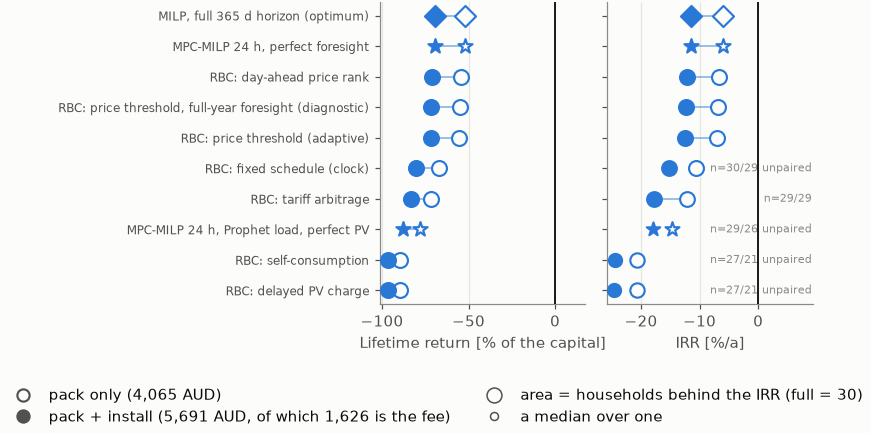

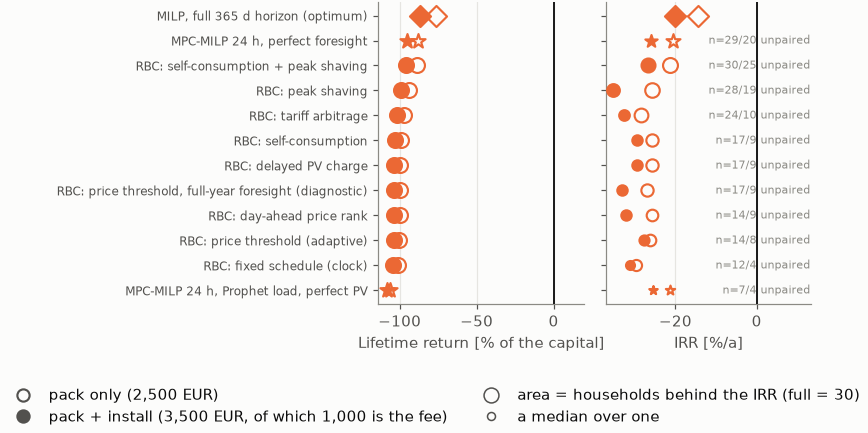

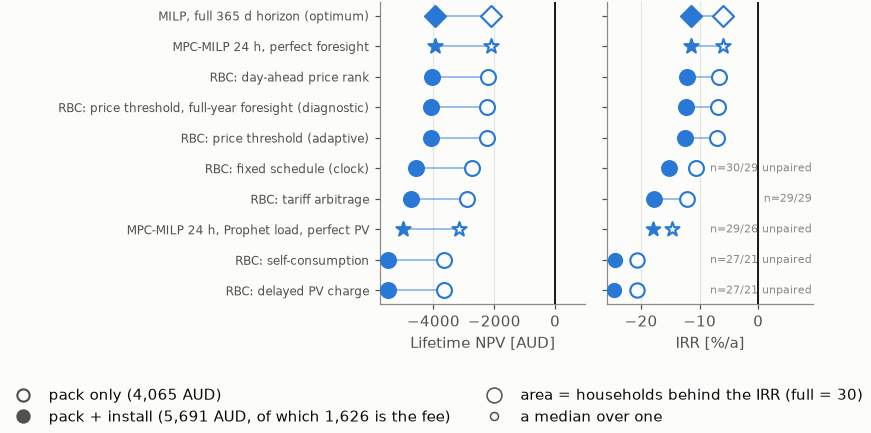

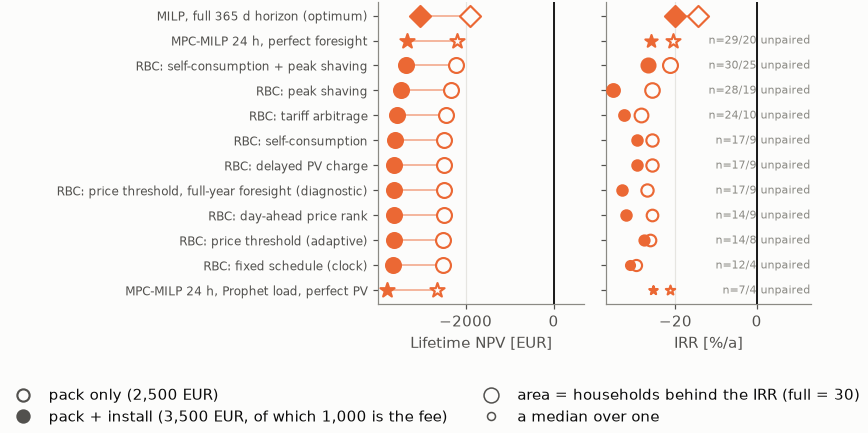

AU (AUD) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                                net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: day-ahead price rank                      270.9     -2204     -6.7  30     -4046    -12.1  30
   MPC-MILP 24 h, Prophet load, perfect PV        162.0     -3170    -14.8  29     -5012    -18.0  26
   MILP, full 365 d horizon (optimum)             281.6     -2110     -6.1  30     -3952    -11.5  30
   n: households of 30 with a defined IRR. `n/a` is "no rate solves it", not a large negative one.
   the 1,626 AUD install alone costs 1,842 AUD of NPV and 5.5 points of IRR on MILP, full 365 d horizon (optimum).

SI (EUR) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                                net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: self-consumption + peak shaving            69.4     -2217    -21.3  30     -3350    -26.7  25
   MPC-MILP 24 

In [13]:
### What the battery is actually worth: lifetime NPV and IRR, and what the install fee costs
# The question every figure above dodges. `saving` and `gain_share_pct` rank
# controllers against each other on one year; NOTHING there says whether the box
# is worth buying, and a ranking of positive-looking savings reads like a
# purchase recommendation. This is the same runs discounted over the pack's life
# against what the pack costs, and the answer is that every marker is to the
# LEFT of break-even on both tariffs.
#
# TWO VERSIONS, and the percentage one is the default:
#
#   ""        ROI -- the lifetime return as a share of the CAPITAL it is a
#             return on -- beside the IRR. Both are percentages, so AU and SI
#             are on one axis and "how far short does this fall" is a single
#             number on either tariff.
#   "_money"  the same thing in the arm's own currency, for the reader who wants
#             the cheque. Two axes, necessarily, because one of them is AUD.
#
# TWO MARKS PER ROW -- the "separate consideration" of the install fee:
#
#   hollow   pack only, 2500 EUR of cells (4065 AUD). "Is storage worth what
#            storage costs?"
#   solid    pack + 1000 EUR hybrid inverter and fitting. What a household pays.
#
# The gap is what the fee is worth over the life; the caveats cell has what it
# costs and why it is reported separately.
#
# WHAT THE CONNECTING LINE MAY AND MAY NOT SAY. An IRR is NaN wherever the
# saving never covers the O&M charge, and `median()` drops NaN per column -- so
# the two ends of a row's IRR pair can be medians over different households, and
# on SI one end of `peak_shaving` is a median over ONE. The line is therefore
# drawn only where both ends are over the SAME households, and the rows where it
# is missing are exactly the rows where no such comparison exists.
import Battery_Economics as be
from matplotlib.lines import Line2D

ECON = [("_pack_only", "pack only", False), ("", "pack + install", True)]

for money in (False, True):
    for tariff, arm in REFERENCE_ARM.items():
        sub, stars = with_wearprice(long, arm)
        sub = sub[sub["controller"] != "no_battery"]
        if sub.empty or sub["npv"].isna().all():
            continue
        cur = hs.currency(arm)
        cols = ["npv", "npv_pack_only", "roi_pct", "roi_pct_pack_only",
                "irr_pct", "irr_pct_pack_only", "capex", "capex_pack_only",
                "lifetime_saving", "lifetime_saving_pack_only"]
        med = sub.groupby("controller")[cols].median()
        med = med.sort_values("npv", ascending=False)   # best first, downward
        ypos = np.arange(len(med))[::-1]
        base = ctrl_color(tariff, "milp_full")

        # HOW MANY HOUSEHOLDS EACH IRR MARKER IS A MEDIAN OVER, and -- new --
        # how many are behind BOTH ends of a pair. The NPV and ROI panels are
        # always over every household, so only the IRR panel carries counts.
        nrs = sub.groupby("controller")[["irr_defined_pack_only",
                                         "irr_defined"]].sum().astype(int)
        # The households that have an IRR under BOTH scenarios. Only on these is
        # the fee's cost in IRR points a statement about the same people.
        paired = (sub.assign(_both=sub["irr_defined"]
                             & sub["irr_defined_pack_only"])
                  .groupby("controller")["_both"].sum().astype(int))
        n_hh = sub["dataset"].nunique()

        def _area(n):
            """Marker area for a median over `n` of `n_hh` households.

            Linear in n rather than sqrt(n): this is not a quantity anyone reads
            off a marker, it is a warning that the marker is thin, and the read
            that has to survive is "that one is smaller than the others".
            """
            return 25.0 + 70.0 * (n / max(n_hh, 1))

        _panels = ([("npv", f"Lifetime NPV [{cur}]"),
                    ("irr_pct", "IRR [%/a]")] if money else
                   [("roi_pct", f"Lifetime return [{PCT_OF_CAPEX}]"),
                    ("irr_pct", "IRR [%/a]")])
        fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.62), sharey=True)
        for ax, (col, unit) in zip(axes, _panels):
            for y, c in zip(ypos, med.index):
                xs = [med.loc[c, col + suf] for suf, _, _ in ECON]
                ns = [nrs.loc[c, "irr_defined" + suf] if col == "irr_pct" else n_hh
                      for suf, _, _ in ECON]
                # THE LINE ONLY WHERE IT IS A COMPARISON. On the NPV and ROI
                # panels both ends are over every household and it always is.
                _same = (col != "irr_pct") or (
                    paired.loc[c] == ns[0] == ns[1] and ns[0] > 0)
                if all(v == v for v in xs) and _same:
                    ax.plot(xs, [y, y], color=base, lw=1.1, zorder=2, alpha=0.55)
                for x, n, (suf, _, solid) in zip(xs, ns, ECON):
                    if x != x:
                        continue
                    ax.scatter([x], [y], s=_area(n), marker=ctrl_marker(c),
                               zorder=3, color=base if solid else SURFACE,
                               edgecolor=base, lw=1.4)
                if col == "irr_pct" and any(n < n_hh for n in ns):
                    _fin = [x for x in xs if x == x]
                    if _fin:
                        # BOTH NUMBERS, ALWAYS -- never deduplicated to one.
                        # "n=29" and "n=30/29" would be two strings of different
                        # arity for the same kind of fact.
                        _txt = "n=" + "/".join(str(n) for n in ns)
                        if not _same and all(v == v for v in xs):
                            # Say why the line is missing, on the row it is
                            # missing from. Otherwise its absence reads as a
                            # rendering slip rather than as the point.
                            _txt += " unpaired"
                        # A RIGHT GUTTER, not a tag hung off the rightmost
                        # marker: hung off the mark, the count lands in the
                        # middle of the panel wherever the two marks are far
                        # apart. Pinned to the axes edge it forms a column that
                        # reads down the figure, as the break-even figure does.
                        ax.annotate(_txt, xy=(0.995, y),
                                    xycoords=("axes fraction", "data"),
                                    ha="right", va="center", color=MUTED,
                                    fontsize=7.5)
            # An IRR that does not EXIST is not a bad IRR, and a blank row would
            # read as a missing run. Said in words, on the row it belongs to,
            # and only where the row is empty -- a row with one mark left
            # carries its count beside that mark already.
            if col == "irr_pct":
                for y, c in zip(ypos, med.index):
                    if all(med.loc[c, "irr_pct" + suf] != med.loc[c, "irr_pct" + suf]
                           for suf, _, _ in ECON):
                        ax.annotate("no IRR", xy=(0, y), xytext=(-4, 0),
                                    textcoords="offset points", ha="right",
                                    va="center", color=MUTED, fontsize=7.5)
            # Break-even is the reading this whole figure exists for, so it is a
            # solid rule rather than a gridline, and it is named in the title,
            # which `titles=False` lifts into the caption.
            ax.axvline(0, color=INK, lw=1.2, zorder=4)
            ax.grid(axis="y", visible=False)
            _l, _r = ax.get_xlim()
            # Room for the gutter column on the IRR panel, which is the only one
            # that carries one; the ROI/NPV panel needs only label headroom.
            ax.set_xlim(_l, _r + (0.30 if col == "irr_pct" else 0.12)
                        * (_r - _l))
            finish(ax, xlabel=unit)

        axes[0].set_yticks(ypos, [LABEL.get(c, c) for c in med.index])
        axes[0].tick_params(axis="y", labelsize=8)
        _fee = med["capex"].iloc[0] - med["capex_pack_only"].iloc[0]
        keys = [
            Line2D([], [], marker="o", ls="", ms=8, color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack only ({med['capex_pack_only'].iloc[0]:,.0f} {cur})"),
            Line2D([], [], marker="o", ls="", ms=8, color=INK_2,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack + install ({med['capex'].iloc[0]:,.0f} {cur}, "
                         f"of which {_fee:,.0f} is the fee)"),
            # THE SIZE ENCODING, DOCUMENTED. Marker area carries the sample
            # behind an IRR median; unstated, it is decoration rather than
            # information.
            Line2D([], [], marker="o", ls="", color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.0,
                   markersize=np.sqrt(_area(n_hh)),
                   label=f"area = households behind the IRR (full = {n_hh})"),
            Line2D([], [], marker="o", ls="", color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.0,
                   markersize=np.sqrt(_area(1)), label="a median over one"),
        ]
        if stars:
            keys.append(Line2D([], [], marker="D", ls="", ms=8, color=SURFACE,
                               markeredgecolor=base, markeredgewidth=1.4,
                               label="* same MILP, per-cycle wear price in its objective"))
        pf.chart_frame(
            fig,
            f"What the battery is worth over its life, {tariff}. The black rule "
            f"is break-even and every controller is to the left of it. The "
            f"{'NPV' if money else 'return'} panel is over all {n_hh} "
            f"households; an IRR exists only where the saving covers the O&M "
            f"charge, so the IRR panel's marker area and the n beside a row are "
            f"the households behind it (pack only / with the fee), and the two "
            f"marks are joined only where the same households are behind both "
            f"-- a row marked `unpaired` has no such comparison to draw",
            handles=keys, ncol=2)
        pf.show(fig, f"lifetime_economics_{tariff.lower()}"
                     f"{'_money' if money else ''}", layout="frame")

# The same thing in numbers, for the three controllers the text names.
for tariff, arm in REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    cur = hs.currency(arm)
    _sub = long[long["arm"] == arm]
    tab = _sub.groupby("controller").median(numeric_only=True)
    # HOW MANY households each IRR median is over, exactly as `IRR_n` does in
    # the summary table. An IRR is NaN where the saving never covers the O&M
    # charge, and pandas drops those before taking a median -- so on SI
    # `peak_shaving` reports -52 %/a from ONE household while `milp_full`
    # reports -29.9 from thirty, and printed side by side with no n they read as
    # a ranking. The NPV beside them is always over all 30, which is the other
    # half of the trap: without these columns the two numbers on one row are
    # medians over different samples.
    nrs = _sub.groupby("controller")[["irr_defined", "irr_defined_pack_only"]].sum()
    _n_hh = _sub["dataset"].nunique()
    picks = [c for c in (hs.best_rule(long, arm), "prophet", "milp_full")
             if c in tab.index]
    # Wide enough for the three names PRINTED, not for every controller in the
    # frame. "RBC: self-consumption + peak shaving" is 36 characters and was
    # being truncated to "RBC: self-consumption + peak shavi" at 34.
    _w = max(len(LABEL.get(c, c)) for c in picks) + 2
    print(f"{tariff} ({cur}) -- median household, 12 y at "
          f"{be.DISCOUNT_RATE:.0%} real, O&M {be.OPEX_FRAC_OF_CAPEX_PER_YEAR:.1%}/a "
          f"of installed capital")
    print(f"   {'controller':<{_w}s}{'net saving':>11s}"
          f"{'NPV pack':>10s}{'IRR pack':>9s}{'n':>4s}"
          f"{'NPV +fee':>10s}{'IRR +fee':>9s}{'n':>4s}")
    for c in picks:
        def _r(v):
            return f"{v:9.1f}" if v == v else f"{'n/a':>9s}"
        print(f"   {LABEL.get(c, c):<{_w}s}{tab.loc[c, 'saving_annual_net']:11.1f}"
              f"{tab.loc[c, 'npv_pack_only']:10.0f}"
              f"{_r(tab.loc[c, 'irr_pct_pack_only'])}"
              f"{int(nrs.loc[c, 'irr_defined_pack_only']):>4d}"
              f"{tab.loc[c, 'npv']:10.0f}{_r(tab.loc[c, 'irr_pct'])}"
              f"{int(nrs.loc[c, 'irr_defined']):>4d}")
    print(f"   n: households of {_n_hh} with a defined IRR. `n/a` is "
          f"\"no rate solves it\", not a large negative one.")
    # The fee IN THIS ARM'S CURRENCY, and named by the controller it is measured
    # on rather than by position: `picks[-1]` is `milp_full` only while
    # `milp_full` is in the frame.
    _on = picks[-1]
    _fee = tab.loc[_on, "capex"] - tab.loc[_on, "capex_pack_only"]
    print(f"   the {_fee:,.0f} {cur} install alone costs "
          f"{tab.loc[_on, 'npv_pack_only'] - tab.loc[_on, 'npv']:,.0f} "
          f"{cur} of NPV and "
          f"{tab.loc[_on, 'irr_pct_pack_only'] - tab.loc[_on, 'irr_pct']:.1f}"
          f" points of IRR on {LABEL.get(_on, _on)}.\n")

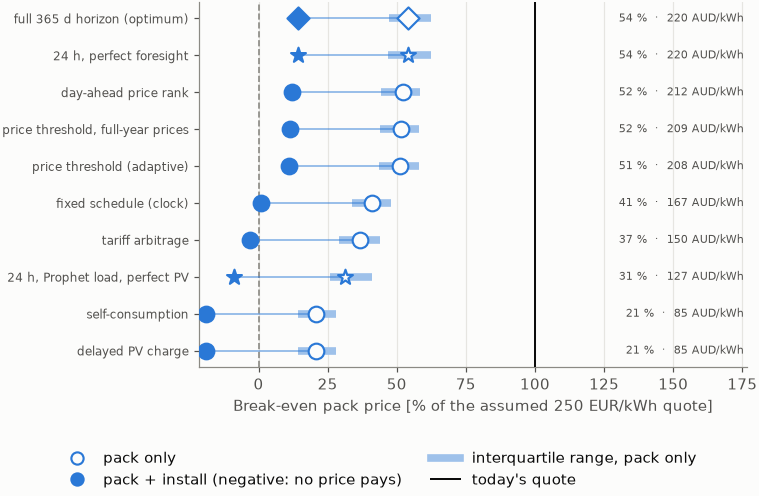

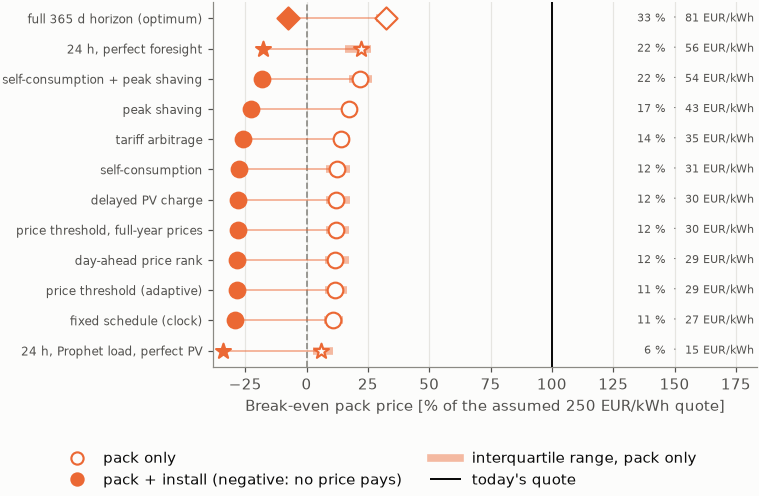

In [14]:
### How far the pack price has to fall: break-even capex
# THE READING THE IRR PANEL CANNOT GIVE. An IRR is NaN wherever the saving never
# covers the O&M charge, so the panel above plots medians over one household
# beside medians over thirty and spends a marker-area encoding, an `n` column
# and a suppressed connector on saying so. Break-even capex is defined for every
# household on every controller, because it is the price at which the annuity
# balances and that price always exists -- simply negative where no positive
# price would do.
#
# AS A SHARE OF THE ASSUMED PRICE, not in currency per kWh: "the pack has to
# reach 37 % of what it costs today" is one sentence on both tariffs, where
# "150 AUD/kWh" and "53 EUR/kWh" are two numbers a reader converts before
# comparing. 100 % is today's quote.
#
# TWO MARKS PER ROW, the same hollow/solid convention as the lifetime figure,
# because the answer is completely different between them and that IS the result:
#
#   hollow  pack only. "Is storage worth what storage costs?" -- and it can be,
#           at 37 % of today's price on AU and 21 % on SI.
#   solid   pack + install. Every value is NEGATIVE: the fixed fee alone is more
#           than the saving can ever recover, so there is no cell price, free
#           included, at which the retrofit pays. A bar that crosses zero is a
#           controller for which the question stops being "how cheap" and starts
#           being "not at any price".
import Battery_Economics as be
from matplotlib.lines import Line2D

for tariff, arm in REFERENCE_ARM.items():
    sub, stars = with_wearprice(long, arm)
    sub = sub[sub["controller"] != "no_battery"]
    if sub.empty or sub["break_even_capex_pack_only"].isna().all():
        continue
    cur = hs.currency(arm)
    # The quote this arm was priced against, in the arm's own money -- the same
    # conversion `summarize` applies, read from the constants rather than typed.
    quote = be.CAPEX_EUR_PER_KWH * hs.ARM_CURRENCY_PER_EUR[tariff]
    work = sub.assign(
        _pack=100.0 * sub["break_even_capex_pack_only"] / quote,
        _full=100.0 * sub["break_even_capex"] / quote)
    med = (work.groupby("controller")
           .agg(pack=("_pack", "median"), full=("_full", "median"),
                q1=("_pack", lambda s: s.quantile(0.25)),
                q3=("_pack", lambda s: s.quantile(0.75)),
                n=("_pack", "count"))
           .sort_values("pack", ascending=False))
    ypos = np.arange(len(med))[::-1]
    base = ctrl_color(tariff, "milp_full")

    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.70))
    for y, (c, r) in zip(ypos, med.iterrows()):
        # The interquartile range on the pack-only reading, because the
        # households disagree by more than the controllers do -- which is itself
        # the result, and the one a purchase decision turns on.
        ax.plot([r["q1"], r["q3"]], [y, y], lw=5.0, solid_capstyle="butt",
                color=pf.mix(base, SURFACE, 0.55), zorder=2)
        # What the fee costs, as the distance between the two marks.
        ax.plot([r["full"], r["pack"]], [y, y], lw=1.1, color=base, alpha=0.55,
                zorder=3)
        _star = is_wearprice(c)
        ax.scatter([r["pack"]], [y], s=105, marker=ctrl_marker(c), zorder=5,
                   color=SURFACE, edgecolor=base, lw=1.4)
        ax.scatter([r["full"]], [y], s=105, marker=ctrl_marker(c), zorder=5,
                   color=base, edgecolor=base, lw=1.4)
        ax.annotate(f"{r['pack']:.0f} %  ·  {r['pack'] * quote / 100:,.0f} "
                    f"{cur}/kWh",
                    xy=(0.995, y), xycoords=("axes fraction", "data"),
                    ha="right", va="center", fontsize=7.5, color=INK_2)
    # TODAY'S PRICE, and the point below which no price helps.
    ax.axvline(100.0, color=INK, lw=1.3, zorder=6)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--", zorder=1)
    ax.set_yticks(ypos, [tick_label(c) for c in med.index])
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)
    _lo = min(0.0, float(med["full"].min())) * 1.12
    ax.set_xlim(_lo, 118.0 + 0.42 * (118.0 - _lo))
    finish(ax, xlabel=f"Break-even pack price [% of the assumed "
                      f"{be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh quote]")
    keys = [Line2D([], [], ls="", marker="o", ms=8, color=SURFACE,
                   markeredgecolor=base, markeredgewidth=1.4,
                   label="pack only"),
            Line2D([], [], ls="", marker="o", ms=8, color=base,
                   markeredgecolor=base, markeredgewidth=1.4,
                   label="pack + install (negative: no price pays)"),
            Line2D([], [], lw=5.0, color=pf.mix(base, SURFACE, 0.55),
                   label="interquartile range, pack only"),
            Line2D([], [], lw=1.3, color=INK, label="today's quote")]
    if stars:
        keys.append(Line2D([], [], ls="", marker="D", ms=8, color=SURFACE,
                           markeredgecolor=base, markeredgewidth=1.4,
                           label="* same MILP, per-cycle wear price in its objective"))
    pf.chart_frame(
        fig,
        f"How far the pack price has to fall before the battery breaks even, "
        f"{tariff}, over {SAMPLE}. Each mark is the price at which that "
        f"controller's saving exactly covers capital recovery and O&M, as a "
        f"share of the {be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh the study assumes. "
        f"The printed figure is the pack-only reading. Unlike an IRR this is "
        f"defined for every household, so every marker is a median over all "
        f"{int(med['n'].max())} of them. With the install fee in, every value "
        f"is negative -- the fixed cost alone exceeds what the saving can "
        f"recover, so no cell price pays, free included",
        handles=keys, ncol=2)
    pf.show(fig, f"break_even_capex_{tariff.lower()}", layout="frame")


In [15]:
### The horizon axis: what 24 h of foresight buys over 11 h
# THE HORIZON AXIS, READ DIRECTLY. In the arm table H24 against H11 is a
# subtraction the reader does by eye across a page. The horizon is the
# gate-closure question -- an 11 h horizon is what a household bidding into a
# day-ahead market actually has -- so it gets a figure.
#
# PAIRED, like everything else here: the same household under both horizons,
# differenced per household and then median'd. A difference of two medians would
# throw away the pairing, and the two medians can come from different households.
#
# The `*_wearprice` arms run at both horizons too, so the figure carries the
# interaction as well: whether a shorter horizon costs more or less when the
# controller is not paying for its cycles.
import textwrap

H_ARMS = {}
for _t in sorted(set(df_all["tariff"])):
    for _suffix, _lab in (("", ""), ("_wearprice", " *")):
        _long_h, _short_h = f"{_t}_H24{_suffix}", f"{_t}_H11{_suffix}"
        if {_long_h, _short_h} <= set(df_all["arm"]):
            H_ARMS[(_t, _lab)] = (_long_h, _short_h)

if H_ARMS:
    _tariffs = sorted({t for t, _ in H_ARMS})
    fig, axes = plt.subplots(1, len(_tariffs), figsize=pf.figsize(ratio=0.60),
                             sharey=True, sharex=True)
    axes = np.atleast_1d(axes)
    for ax, tariff in zip(axes, _tariffs):
        rows = []
        for (t, lab), (a_long, a_short) in H_ARMS.items():
            if t != tariff:
                continue
            wide = (long[long["arm"].isin((a_long, a_short))]
                    .pivot_table(index=["dataset", "controller"], columns="arm",
                                 values="saving_total_pct", observed=True))
            if a_long not in wide or a_short not in wide:
                continue
            # Only the MPC controllers see the horizon at all. A rule has no
            # horizon, and `milp_full` solves the whole year under both arms --
            # their rows are the same numbers twice, and putting them on a chart
            # about horizons would say there is something to read.
            for c in ("prophet", "oracle"):
                d = (wide[a_long] - wide[a_short]).xs(c, level="controller",
                                                      drop_level=True).dropna()
                if len(d):
                    rows.append((LABEL.get(c, c) + lab, float(d.median()),
                                 float(d.quantile(0.25)), float(d.quantile(0.75)),
                                 len(d)))
        if not rows:
            continue
        rows.sort(key=lambda r: r[1])
        y = np.arange(len(rows))
        for yi, (_lab, m, q1, q3, n) in zip(y, rows):
            ax.plot([q1, q3], [yi, yi], lw=5.0, solid_capstyle="butt",
                    color=pf.mix(TARIFF_COLOR[tariff], SURFACE, 0.5), zorder=2)
            ax.scatter([m], [yi], s=90, zorder=4, color=TARIFF_COLOR[tariff],
                       edgecolor=SURFACE, lw=1.0)
            ax.annotate(f"{m:+.1f}", xy=(m, yi), xytext=(0, 9),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=7.5, color=INK_2)
        ax.set_yticks(y, [textwrap.fill(r[0], 26) for r in rows])
        ax.tick_params(axis="y", labelsize=7.5)
        ax.axvline(0, color=INK, lw=1.2, zorder=5)
        ax.grid(axis="y", visible=False)
        ax.set_ylim(-0.7, len(rows) - 0.3)
        ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                    ha="right", va="bottom", color=TARIFF_COLOR[tariff],
                    fontsize=13, fontweight="semibold")
    fig.supxlabel("What the longer horizon buys "
                  "[percentage points of the no-battery bill, H24 − H11]",
                  color=INK_2, fontsize=10)
    pf.chart_frame(
        fig,
        f"What 24 h of foresight buys over 11 h, paired per household over "
        f"{SAMPLE}. Positive is the longer horizon winning. Only the "
        f"receding-horizon controllers appear: a rule has no horizon, and the "
        f"whole-period solve sees the same year under both arms",
        subtitle="Marker: the median household. Bar: the interquartile range "
                 "across households. * same MILP, per-cycle wear price in its objective",
        handles=[])
    pf.show(fig, "horizon_effect", layout="frame")
else:
    print("The H11 arms have not run; the horizon figure needs both horizons.")


The H11 arms have not run; the horizon figure needs both horizons.


### 4.1 Household heterogeneity

Every figure above is a median over the roster. These two ask the question a median cannot: is the forecast's regret concentrated in a few households, and do those households have anything in common?


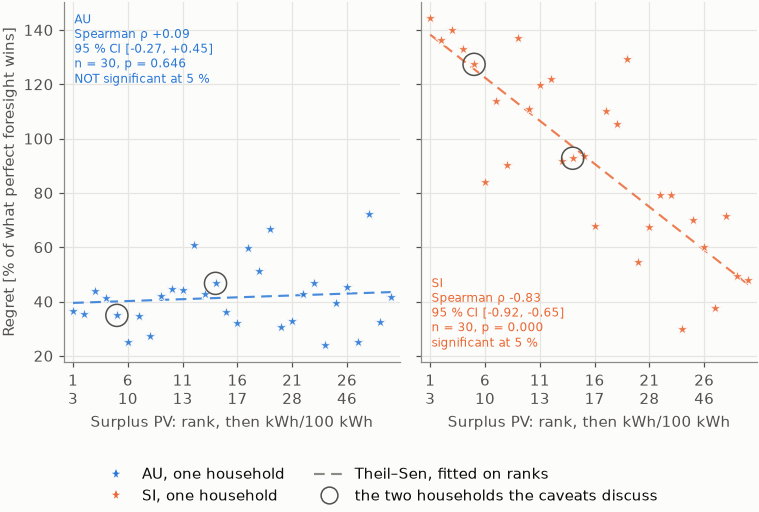

In [16]:
### Which households is the forecast bad at?
from matplotlib.lines import Line2D
from scipy import stats as st

# The two households the caveats cell names, because they disagree about which
# channel Prophet is good at; marked here so that discussion has a picture.
# Ringed rather than labelled -- see the note at the ring itself.
CAVEAT_HH = ["Ausgrid 127", "Ausgrid 148"]

# Which households is the forecast bad at, and is the answer a gradient?
#
# DRAWN IN THE SPACE THE TEST MEASURES. Spearman is a rank statistic and knows
# nothing about the spacing of its inputs, so x is the RANK of surplus PV, 1 to
# 30. Evenly spaced by construction, every household carries the same visual
# weight it has in the statistic, and the monotone trend the coefficient
# describes is the trend the eye sees. On the raw axis -- 4 to 96, two thirds of
# the households under 30 -- the eye reads a clump and four stragglers instead.
# The raw values stay readable as a second tick row, because the axis still has
# to mean something physical.
#
# THEIL-SEN RATHER THAN OLS, and only because the space is rank-rank: a median
# of pairwise rank slopes is the same family of object as the coefficient, so it
# adds direction and strength without claiming a functional form. An OLS line
# through raw values would assert a slope in units Spearman never looked at.
#
# Rho carries its interval: `rho +0.63, p = 0.0002` and `rho +0.63, 95 % CI
# [+0.36, +0.81]` are the same estimate, and only the second says how firmly.

_HET = ["con_skill_vs_naive", "gen_skill_vs_naive",
        "buy_no_battery", "sell_no_battery"]
het = (long[(long["controller"] == "prophet")
            & (long["arm"].isin(REFERENCE_ARM.values()))]
       .join(df_all.set_index(["arm", "dataset"])[_HET], on=["arm", "dataset"])
       .assign(pv_ratio=lambda d: 100.0 * d["sell_no_battery"]
               / d["buy_no_battery"]))

# Both axis labels are centred on a HALF-WIDTH axes and are longer than one, so
# the height carries them: at 0.64 the two x labels meet in the middle of the
# figure and the y label runs off the top. Height is the knob -- the width is
# fixed at \textwidth -- and the labels below are cut to what a 3.1 in panel
# holds.
fig, axes = plt.subplots(1, len(REFERENCE_ARM),
                         figsize=pf.figsize(ratio=0.72), sharey=True)
axes = np.atleast_1d(axes)
rhos = {}
for ax, tariff in zip(axes, sorted(REFERENCE_ARM)):
    s = het[het["tariff"] == tariff].sort_values("pv_ratio")
    col = fs.TARIFF_COLOR[tariff]
    xr = st.rankdata(s["pv_ratio"].to_numpy())
    y = s["regret_pct_of_gain"].to_numpy()
    # The star is the MPC family marker: every point here is the same
    # controller, the arm's Prophet MPC, seen on thirty different households.
    ax.scatter(xr, y, s=62, marker=fs.FAMILY_MARKER["MPC"], color=col,
               edgecolor=SURFACE, lw=0.7, alpha=0.9, zorder=3)

    # THEIL-SEN IN RANK SPACE. The median of the pairwise slopes, which is
    # the rank-based line the rank-based coefficient describes -- not an OLS
    # fit, which would be a claim about magnitudes in a plane that has none.
    sl, ic, _, _ = st.theilslopes(y, xr)
    xx = np.array([xr.min(), xr.max()])
    ax.plot(xx, ic + sl * xx, color=col, lw=1.4, ls=(0, (5, 3)), zorder=2,
            alpha=0.85)

    rho, p, lo, hi, n = fs.spearman_ci(s["pv_ratio"], y)
    rhos[tariff] = (rho, p, lo, hi)
    fs.corner_block(ax, fs.rho_lines(tariff, rho, p, lo, hi, n), col, y)

    # RINGED, NOT LABELLED. Both households sit in the low-PV cluster where
    # the points are densest, and a sweep of every sensible text offset put
    # one label on another household's marker on at least one panel. The
    # ring says "these two are the pair the caveats discuss"; the strip
    # figure, where every household has its own row, says which is which.
    sel = s["dataset"].isin(CAVEAT_HH).to_numpy()
    ax.scatter(xr[sel], y[sel], s=210, marker="o", facecolor="none",
               edgecolor=INK_2, lw=1.0, zorder=4)

    # THE RAW VALUE, on a second tick row, so the rank axis still means
    # something physical. Every fifth rank, which is as many numbers as fit.
    ax.set_xlim(0.2, len(xr) + 0.8)
    ticks = np.arange(1, len(xr) + 1, 5)
    ax.set_xticks(ticks, [f"{int(t)}\n{s['pv_ratio'].to_numpy()[int(t)-1]:.0f}"
                          for t in ticks])
    finish(ax, xlabel="Surplus PV: rank, then kWh/100 kWh")
finish(axes[0], ylabel=f"Regret [{fs.PCT_OF_GAIN}]")

keys = [Line2D([], [], ls="", marker=fs.FAMILY_MARKER["MPC"], ms=9,
               color=fs.TARIFF_COLOR[t], markeredgecolor=SURFACE,
               label=f"{t}, one household") for t in sorted(REFERENCE_ARM)]
keys += [Line2D([], [], color=MUTED, lw=1.4, ls=(0, (5, 3)),
                label="Theil–Sen, fitted on ranks"),
         Line2D([], [], ls="", marker="o", ms=11, markerfacecolor="none",
                color=INK_2, markeredgewidth=1.0,
                label="the two households the caveats discuss")]
pf.chart_frame(
    fig,
    f"Prophet's regret is not spread evenly, and what predicts it reverses "
    f"between the tariffs: the more surplus PV a household has, the WORSE "
    f"the forecast does on AU (ρ {rhos['AU'][0]:+.2f}, 95 % CI "
    f"[{rhos['AU'][2]:+.2f}, {rhos['AU'][3]:+.2f}]) and the BETTER on SI "
    f"(ρ {rhos['SI'][0]:+.2f}, [{rhos['SI'][2]:+.2f}, {rhos['SI'][3]:+.2f}])",
    subtitle=f"One point per household, {SAMPLE}, {REFERENCE_ARM['AU']} "
             f"and {REFERENCE_ARM['SI']}. x is the RANK of the "
             f"household's own export over its own import without a battery "
             f"-- a property of the house, not of a controller -- because "
             f"Spearman is a rank statistic and the raw axis, two thirds of "
             f"it under 30, draws a shape the coefficient does not describe. "
             f"The raw value is the second tick row. Cluster id and distance "
             f"to centroid were tested and explain nothing (|ρ| < 0.15, "
             f"p > 0.4): the households do not fall into kinds, they fall on "
             f"a gradient",
    handles=keys, ncol=2)
pf.show(fig, "household_heterogeneity", layout="frame")

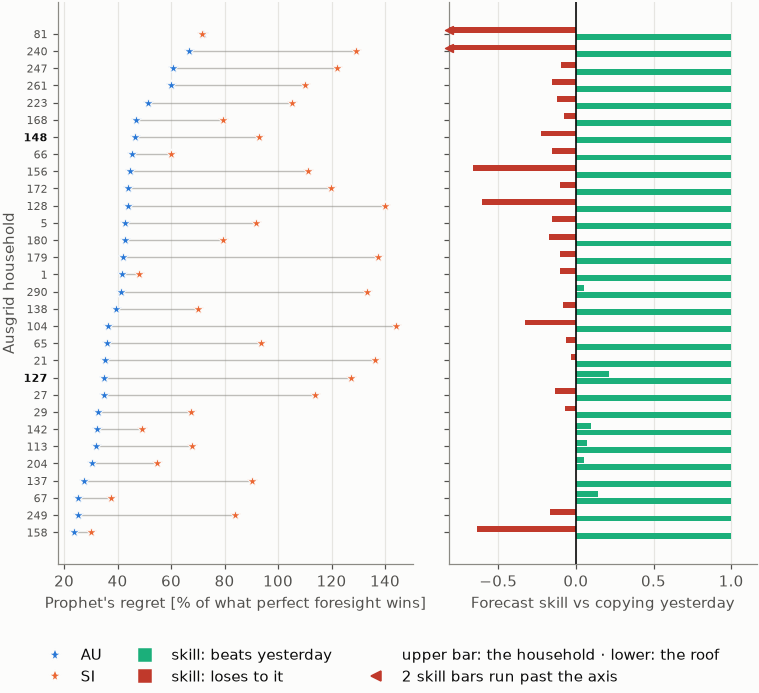

In [17]:
### Every household, its regret and its forecast, side by side
# THE ROW ORDER IS THE REGRET, and everything else is read against it. Sorted by
# AU regret because some order has to be chosen and the cluster ids carry none;
# the SI mark on the same row then shows whether the two tariffs agree about
# which households are hard, and the skill panel whether the forecast's own
# error explains the ordering. Both answers are visible and both are negative,
# which is why this figure exists next to the scatter rather than instead of it.
#
# The regret panel puts AU and SI on ONE x axis. That is only legal because the
# measure is a share of what perfect foresight wins on that same household --
# the one form in which an AUD result and a EUR result are the same quantity.
from matplotlib.lines import Line2D
from scipy import stats as _st


_strip = (het.pivot_table(index="dataset", columns="tariff",
                          values="regret_pct_of_gain")
          .join(het[het["tariff"] == "AU"]
                .set_index("dataset")[["con_skill_vs_naive",
                                       "gen_skill_vs_naive"]]))
# The forecast is fitted per household and cached there, so the two skill
# columns are identical under every arm -- reading them off the AU rows is not
# a choice of tariff, it is the only value they have.
_strip = _strip.sort_values("AU", ascending=False)
ypos = np.arange(len(_strip))[::-1]
# `clip_window` on the skill axis, for the reason the skill/regret figure above
# gives: Ausgrid 81 stretches it over a range the other twenty-nine never use.
_skv = pd.concat([_strip["con_skill_vs_naive"], _strip["gen_skill_vs_naive"]])
# Only the NEGATIVE tail is clipped. `clip_window`'s second argument is the list
# of values the window must keep, so passing the maximum forces the upper bound
# open: the positive side tops out at +0.21, and that value is Ausgrid 127 --
# the household this whole section is about, which must not be clipped.
_swin = clip_window(_skv.to_numpy(), [_skv.max(), 0.0], q=0.04, pad=0.10)
_sout = 0

fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.95), sharey=True,
                         gridspec_kw={"width_ratios": [1.15, 1.0]})
ax_r, ax_s = axes

for y, (_hh, r) in zip(ypos, _strip.iterrows()):
    _v = [r[t] for t in sorted(REFERENCE_ARM) if r[t] == r[t]]
    if len(_v) > 1:
        ax_r.plot([min(_v), max(_v)], [y, y], color=MUTED, lw=0.9, zorder=2,
                  alpha=0.55)
    for t in sorted(REFERENCE_ARM):
        if r[t] == r[t]:
            ax_r.scatter([r[t]], [y], s=52, marker=FAMILY_MARKER["MPC"],
                         color=TARIFF_COLOR[t], edgecolor=SURFACE, lw=0.6,
                         zorder=3)
    # TWO THIN BARS FROM ZERO, upper = the household, lower = the roof, each
    # coloured by sign the way cell 14 colours the same quantity. Zero is
    # "copying yesterday", so a bar to the left is a forecast that lost to it.
    for _off, _col in ((0.20, "con_skill_vs_naive"), (-0.20, "gen_skill_vs_naive")):
        _s = r[_col]
        if _s != _s:
            continue
        _clip = min(max(_s, _swin[0]), _swin[1]) if _swin else _s
        ax_s.barh(y + _off, _clip, height=0.34, zorder=3,
                  color=BEATS if _s > 0 else LOSES)
        if _swin and _clip != _s:
            _sout += 1
            ax_s.scatter([_clip], [y + _off], s=26,
                         marker="<" if _s < _clip else ">",
                         color=BEATS if _s > 0 else LOSES, zorder=5,
                         clip_on=False)

if _swin:
    ax_s.set_xlim(*_swin)
ax_s.axvline(0, color=INK, lw=1.1, zorder=4)
for ax in axes:
    ax.grid(axis="y", visible=False)
ax_r.set_yticks(ypos, [d.split()[-1] for d in _strip.index])
ax_r.tick_params(axis="y", labelsize=7.5)
# The two the caveats name, findable without counting rows.
for _t, _d in zip(ax_r.get_yticklabels(), _strip.index):
    if _d in CAVEAT_HH:
        _t.set_color(INK)
        _t.set_fontweight("bold")
finish(ax_r, xlabel=f"Prophet's regret [{PCT_OF_GAIN}]")
finish(ax_s, xlabel="Forecast skill vs copying yesterday")
ax_r.set_ylabel("Ausgrid household", color=INK_2)

# The two readings this figure exists to make, computed rather than asserted.
_agree, _pa = _st.spearmanr(_strip["AU"], _strip["SI"])
_ord, _po = _st.spearmanr(_strip["AU"],
                          _strip[["con_skill_vs_naive",
                                  "gen_skill_vs_naive"]].mean(axis=1))
_nc = int((_strip["con_skill_vs_naive"] > 0).sum())
_ng = int((_strip["gen_skill_vs_naive"] > 0).sum())

_keys = [Line2D([], [], ls="", marker=FAMILY_MARKER["MPC"], ms=9,
                color=TARIFF_COLOR[t], markeredgecolor=SURFACE, label=t)
         for t in sorted(REFERENCE_ARM)]
_keys += [Line2D([], [], marker="s", ls="", ms=8, color=BEATS,
                 label="skill: beats yesterday"),
          Line2D([], [], marker="s", ls="", ms=8, color=LOSES,
                 label="skill: loses to it"),
          Line2D([], [], ls="", marker=None,
                 label="upper bar: the household · lower: the roof")]
if _sout:
    _keys.append(Line2D([], [], ls="", marker="<", ms=7, color=LOSES,
                        label=f"{_sout} skill bars run past the axis"))

pf.chart_frame(
    fig,
    f"The two tariffs do not agree about which households are hard "
    f"(ρ {_agree:+.2f}, p = {_pa:.2f}, n = {len(_strip)}), and forecast skill "
    + (f"orders the regret only weakly (ρ {_ord:+.2f}, p = {_po:.2f})"
       if _po < 0.05 else
       f"does not order the regret either (ρ {_ord:+.2f}, p = {_po:.2f})"),
    subtitle=f"One row per household, {SAMPLE}, sorted by AU regret -- not by "
             f"cluster, whose ids are 1:1 with the households and carry no "
             f"order. Skill is a property of the household: the forecast is "
             f"fitted and cached per house, so both tariffs and both horizons "
             f"see the same number. {_nc} of {len(_strip)} households have a "
             f"consumption channel that beats copying yesterday and {_ng} has "
             f"a generation channel that does; Ausgrid 127 and 148, in bold, "
             f"are the pair that disagree about which channel is the better one",
    handles=_keys, ncol=3)
pf.show(fig, "household_regret_strip", layout="frame")

## 5. Read-out

The households are **paired** — every one is run under every arm — so the per-site
difference is the unit of analysis, and a box plot of two independent-looking
distributions understates the evidence. Wilcoxon signed-rank rather than a t-test: 30 sites
of cost differences are not plausibly normal and a few of them sit far out.

In [18]:
### Every controller against the arm's own forecast-driven MPC, household by household
# NAMED FROM THE ARM, not from the word "Prophet". `hs.paired_controllers`
# compares against the `prophet` CONTROLLER, which is "the MILP on whatever this
# ARM forecasts with" -- a 14-day median on `*_median14`, and a Prophet load
# model reading tomorrow's roof on `*_pvtruth`. The header used to say Prophet
# regardless, which on this track names a forecaster no arm in the notebook ran.
for tariff, arm in REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    rep = hs.paired_controllers(long, arm, reference="prophet")
    if rep.empty:
        continue
    # CANONICAL CONTROLLER ORDER, like every other table in this notebook.
    # `paired_controllers` pivots, so its rows arrive sorted alphabetically by
    # the raw controller key, which is not the order the summary above uses.
    _rank = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
    rep = (rep.assign(_c=rep["comparison"].str.split(" - ").str[0].map(_rank))
              .sort_values("_c").drop(columns="_c"))
    # 56 wide: the longest label, "RBC: price threshold, full-year foresight
    # (diagnostic)", is 54 characters. The IQR field is 20 rather than 18
    # because "[-116.96, -101.00]" is exactly 18 and would butt against the
    # median with no space between them.
    _w = max(len(LABEL.get(c, c)) for c in _rank) + 2
    _ref = ps.mpc_name(arm)
    print(f"=== {tariff} ({arm}): controller - {_ref}, per household ===")
    print(f"{'comparison':{_w}s}{'median':>9s}{'IQR':>20s}{'better':>8s}{'worse':>7s}{'p':>10s}")
    for _, r in rep.iterrows():
        name = r['comparison'].split(' - ')[0]
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"{LABEL.get(name, name):{_w}s}{r['median_diff']:9.2f}"
              f"{f'[{r.q1_diff:.2f}, {r.q3_diff:.2f}]':>20s}"
              f"{r['n_b_greater']:>8d}{r['n_a_greater']:>7d}{p:>10s}")
    print(f"  negative median = the controller is CHEAPER than {_ref}")
    print()

### And every arm against its tariff's reference arm
for tariff in sorted(set(df_all["tariff"])):
    rep = hs.paired_arms(df_all, tariff, metric="cost_prophet")
    if rep.empty:
        continue
    print(f"=== {tariff}: arm - {REFERENCE_ARM[tariff]}, per household ===")
    for _, r in rep.iterrows():
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"  {r['comparison']:44s}{r['median_diff']:9.2f}  p={p}")
    print()

=== AU (AU_H24_pvtruth): controller - MILP+Prophet load, perfect PV, per household ===
comparison                                                 median                 IQR  better  worse         p
No battery                                                 161.97    [135.06, 213.27]       0     30    0.0000
RBC: self-consumption                                       48.49      [-4.57, 93.77]       8     22    0.0024
RBC: fixed schedule (clock)                                -45.14    [-54.37, -31.23]      29      1    0.0000
RBC: delayed PV charge                                      48.93      [-4.57, 93.79]       8     22    0.0022
RBC: price threshold (adaptive)                            -89.74    [-99.09, -76.19]      30      0    0.0000
RBC: day-ahead price rank                                  -92.93   [-102.15, -80.67]      30      0    0.0000
RBC: price threshold, full-year foresight (diagnostic)     -90.88    [-99.48, -78.48]      30      0    0.0000
RBC: tariff arbitrage    

### Caveats

Everything below was measured on this study's sweep, and most of it is structural — the
tariffs, the battery, the wear accounting, the bound assertion, the port's two departures from
its source — and holds unchanged for this notebook's 10 arms. Three qualifications are
specific to this track and are stated here rather than left to be inferred:

* **There are no `*_wearprice` arms here**, so the wear-price bullet below describes an
  ablation that lives in `CODE_PV_FORECAST.ipynb`. It is kept because the wear *accounting* it
  describes applies to every arm in this notebook.
* **Where a bullet counts methods, this track carries five, not seven.** The skill–regret and
  heterogeneity statistics quoted below were computed over the deployable-forecast roster;
  this notebook's own values are in the corner blocks of `skill_vs_regret` and
  `household_heterogeneity`, drawn from these arms, and those are the ones to quote for this
  track.
* **The forecast-quality bullets are about the LOAD channel here.** The roof is the truth in
  every arm of this notebook and has no error to have a skill about; a statement below about
  Prophet's generation channel describes the arms it is measured on, not these.

* **The `*_wearprice` ablation is priced in EUR on both tariffs.** Its per-cycle price is
  `cycle_cost_eur_per_efc(10 kWh)` — 0.4167 — unconverted, so the AU ablation dispatches
  against a pack valued at 250 **AUD**/kWh (154 EUR/kWh). It only steers that ablation's
  dispatch: no saving, total or NPV subtracts it (it is reported as `wear_shadow_eur`), and
  every money figure prices the pack through its life at the converted quote. The main arms
  carry no per-cycle price at all.

* **The rule tuning is in-sample.** Every quantile, window and share in the roster is fitted
  per tariff (`tune_rules.py`, `tune_fixed_schedule.py`; the tables are `hs.RULE_PARAMS` and
  `hs.FIXED_SCHEDULE_WINDOWS`) on four households on AU and two on SI — the same year the
  study scores. The rules therefore carry a small optimistic bias that the MILP arms do not.
  With one or two parameters each and grids this coarse it should be slight, and the
  per-household worst case is printed beside every winner, but it is a real asymmetry.

* **The MPC arms optimise energy only.** On SI they are then billed an excess-power charge
  they never saw in their objective, which is why a peak-shaving rule can beat them there —
  and over the full scored year it does, on every one of the 30 households:
  `self_consumption_peak_shaving` is 38.93 EUR/a cheaper than MPC+Prophet on the median
  household (section 5). That is a statement about those objectives, not about MILP:
  `milp_full` carries the excess-power charge and the contract, and is not beaten. Giving the
  receding-horizon arms the same terms is the obvious next step and is not done here.

* **The saving is against the energy bill, not the invoice.** The standing charge is reported
  as `Fixed_EUR` and excluded from `Cost_EUR`. On AU no controller can move it — it is
  705.30 AUD/a on every household — and it is not small beside the bill it sits next to:
  705.30 AUD/a against a 791.67 AUD/a energy bill on Ausgrid 127, so a "40 % saving" on that
  bill is 21 % of what the household actually writes a cheque for. On SI it is *not* fixed —
  it moves with the dogovorjena moč the controller's own peaks agree to, 75.58 to
  251.94 EUR/a across these households — which is why every SI comparison in this notebook is
  made on the total rather than on `Cost_EUR`.

* **A percentage on AU is not a percentage on SI — unless it is a share of the same thing.**
  Money is not comparable across the two: different currencies over different bills, so
  `saving` in the arm's own units only settles comparisons *down* a tariff. Where the figures
  can, they divide by something each household has one of — its own no-battery bill, the gain
  perfect foresight wins on it, the capital invested in it — and those shares are comparable
  across tariffs because the denominator travels with the numerator. The remaining money
  figures carry both units on the label and are not meant to be read across.

* **A per-cycle wear price is the ablation, and it costs money.** The `*_wearprice` arms put
  0.417 EUR/EFC back into the MILP objective and change nothing else. The MILP then cycles
  about half as hard (127 against 243 EFC/a for `milp_full` on AU) and comes out **behind**
  its wear-free twin: `milp_full` and `oracle` on 30 of 30 households on both tariffs
  (`milp_full` −34 AUD/a, −300 AUD of NPV on AU; −7 EUR/a on SI). Under a 6000 EFC rating
  and a 12-year calendar band no controller here cycles enough to end the pack early, so the
  price holds back cycles nobody bills. Two things the figures state:

  - The accounting is identical across the pair. The pack is paid for once, as capex in the
    NPV; the per-cycle rate is reported as `wear_shadow_eur` and subtracted from nothing.
  - A cycle costs money only where it ends the pack before its calendar band — above
    ~500 EFC/a, where the NPV discounts over the shorter life. `life_binds_on_cycles` marks
    those rows; on this sweep there are none.

* **On SI there is no arbitrage to tune for.** GEN-I Dinamični lands on these profiles at
  0.074–0.088 EUR/kWh — a 0.014 spread, which round-trip losses alone nearly consume. The best `price_threshold`
  on a 44-point grid earns 0.25 EUR/a, and `price_rank_daily`'s unconstrained optimum is to
  stop trading altogether. The two peak-shaving rules earn 33–36 EUR/a on the same
  households. SI's money is the capacity charge, and a price rule cannot reach it.

* **Every controller has perfect foresight of the price** inside its horizon. On AU that is
  close to true (pre-dispatch is published); it is the load and the roof that are forecast.

* **Which channel Prophet is good at varies by household**, and the study should not claim
  otherwise until the full panel is in. On Ausgrid 127 the PV model scores −0.13 skill against
  seasonal-naive while consumption scores +0.21; on Ausgrid 148 the ordering is the other way
  round — the roof is the better of the two (−0.10) and the household the worse (−0.23) —
  though on that site neither channel beats seasonal-naive at all. Six of the 30 households
  have a consumption channel that beats yesterday; not one has a generation channel that
  does. That variation is why the `*_pvnaive` and `*_pvtruth` arms exist: a single forecast
  arm averages the two channels into one number and hides which one carries the result.
  `household_regret_strip` plots it, and the panel beside it shows that the skill ordering
  does not reproduce the regret ordering — against the mean of the two channels it is
  ρ = −0.41 at p = 0.02 — it does order the regret, weakly, on 30 households.

* **What sorts the households is how much surplus PV they have, and it sorts them in opposite
  directions on the two tariffs.** Prophet's regret rises with the household's
  export-to-import ratio on AU (Spearman ρ = +0.39, 95 % CI [+0.02, +0.68], n = 30) and falls
  with it on SI (ρ = −0.84, [−0.92, −0.65]) — see `household_heterogeneity`. The two tariffs
  therefore do not agree about which households are hard (ρ = +0.05, p = 0.79), which is worth stating because
  every other figure in the notebook is a roster median and cannot show it. Cluster id and
  `dist_to_centroid` were both tested and explain nothing (|ρ| < 0.15, p > 0.4); the 30
  households are the centroid-nearest member of each of 30 clusters, so the cluster id is 1:1
  with the household and carries no order to sort by.

* **Skill buys value, on the paired reading.** Inside each household, across the seven
  methods, then across households, the skill–regret correlation is negative on **29 of 30**
  households on AU and **30 of 30** on SI, sign test p = 6e-8 and p = 2e-9. The
  between-method reading — seven method medians against seven — now agrees (AU ρ = −0.96,
  p = 0.0005), though seven points support little and its bootstrap interval says so. Both
  are printed on `skill_vs_regret`; the paired one is the claim.

* **The best forecast is not the same one on both tariffs, and public holidays are not where
  forecasts break.** Both results are in `FIGURES_FORECAST.ipynb`, which runs off these same
  caches. `hbd_median14` wins AU by 0.80 pp of the achievable gain (p < 0.0001, better on 30
  of 30 households) and *loses* SI to plain `median14` by 2.23 pp (p = 0.0001, 23 of 30) — and
  the swap survives handing both a perfect PV forecast, so it is a consumption-channel effect,
  not a roof one. Public holidays, meanwhile, do not lower these households' consumption at
  all (+0.017 against their own workdays, p = 0.18, and the same test finds the weekend at
  p = 1e-4). What does break the forecasts is household absence: 37 runs across 22 of the 30
  houses, on which Prophet's error rises to ×1.53 while copying yesterday's falls to ×0.22,
  and Prophet throws away 48 % of the day's achievable gain against 11 % on a normal day.

* **The competing method is a port, and it departs from its source on purpose in two
  places.** `hbd` is the forecaster of Perez-Pineiro, Skogestad & Boyd, *Home battery dispatch
  under a tiered peak power tariff* (Optimization and Engineering, 2026;
  [cvxgrp/home-battery-dispatch](https://github.com/cvxgrp/home-battery-dispatch)), transcribed
  in `Main/hbd_forecast.py` with every departure marked `DEPARTURE` at the line it happens.
  Two of them change what the numbers mean:

  1. **The quantile.** The paper fits its load baseline at `eta = 0.2`, a baseline
     deliberately biased *high* because its tiered peak-power tariff punishes walking into a
     higher tier. This study fits **both channels at the median** (`eta = 0.5`): every other
     method in the roster is a median-ish estimator, so importing that bias would confound
     "this method is better" with "this forecast is biased", and neither tariff modelled here
     has the tiered structure the bias is *for*. The quantile is a knob on the adapter
     (`eta_con`, `eta_gen`), and pricing it is a separate experiment.
  2. **`hbd_median14` is not their method.** It is their stage 2 — the residual AR — on this
     study's own stage 1, a 14-day median at the same clock position. It is reported as a
     variant, not as the reference implementation, and it is the one that wins: on the
     screening table it is the best forecaster on both channels (skill +0.23 / +0.13), while
     the faithful port scores +0.13 / +0.06 and its baseline-only ablation +0.01 / −0.12. The
     transferable idea is the DECOMPOSITION, not the Fourier basis.

  The horizon differs too, and is not a departure so much as a different problem: the
  reference dispatches against a monthly peak tier, this study against a time-of-use rate and
  an agreed-power charge, so the AR is fit for one day of horizon on one day of lookback.

* **`price_oracle` is a diagnostic.** It reads the whole year and is never a recommendation;
  it exists to split the gap to the MILP into "the rule is too simple" and "the rule cannot
  see the future".

* **One battery size.** 10 kWh nameplate at 1.5 kW throughout. The capacity sweep
  (2.5–30 kWh) is not in this notebook.

* **The whole-period bound is asserted, not assumed.** On AU it is over `Cost_EUR` directly;
  on SI over the **total**, because the dogovorjena moč is endogenous — the solve buys a
  cheaper contract, so its standing charge is part of the same decision and cannot be held
  fixed while the rest is optimised. `full_period_bound_check` asserts this per run and says
  so loudly if a controller ever gets underneath it. Below a horizon of two months it
  declines to claim a bound at all, since no month then reads its contract from another month
  in the window.

* **The battery does not pay for itself on either tariff, under either capex.** Best NPV is
  −3952 AUD on AU and −3044 EUR on SI with the install fee, −2110 AUD and −1911 EUR without
  it — both from `milp_full`, i.e. from a controller nobody can deploy. The comparison in this
  notebook is therefore between *control strategies for a pack that has already been bought*,
  and none of its rankings should be read as an investment case.

  The 1000 EUR install is reported separately rather than folded in because it changes the
  KIND of answer, not only its size. It is 29 % of the SI capital, it does not scale with pack
  size, and because O&M is charged as a share of installed capital it drags 15 EUR/a behind
  it. With the fee in, the O&M charge alone (52.5 EUR/a) exceeds the median saving of most SI
  controllers, so their IRR does not exist rather than being merely bad; without it the charge
  is 37.5 EUR/a and `self_consumption`, `peak_shaving` and the price rules acquire one.
  Neither reading is the "right" one — one answers "does the retrofit pay", the other "is
  storage worth what storage costs" — so the figure plots both and the summary table quotes
  the one the household actually writes a cheque for.


## 6. What each arm cost to run

Every table above ranks the arms by what they **earn**. This one ranks them by what they
**cost to compute**, which is the other half of whether a method is deployable: a forecast
worth a couple of EUR a year that needs a nightly Prophet fit is a different proposition
from one that needs a rolling median.

Wall clock per household, as the sweep actually ran it — `N_JOBS` households at once, one
thread each — so the column ranks the arms against each other on this machine rather than
stating what an arm would take alone on an idle one.

**The cache is in these numbers, not averaged out of them.** One worker runs every arm of
one household in `ARM_ORDER`, so the first arm to need a forecaster or a forecast-blind
oracle pays for it and every later arm that reads the same cache does not. That, and not a
harder model, is why `SI_H24` sits above the 14 SI arms that follow it, and why one arm
of each `hbd` pair carries the 48-quantile-regression fit for both.

**Two sittings, and `ran_on` says which.** The eight `hbd` arms were measured days later
than the other 23, against caches those had already warmed, and the reconstruction cannot see
across that gap — `AU_H24_hbd`'s thirty gaps are all ~2.7 days, which `cap_s` rejects. The
table therefore holds the cache payer of *each* sitting (`SI_H24` and `AU_H24_hbd_median14`),
and those two are not each other's peers: read the ranking **within** a `ran_on` date, not
down the whole column. The `sum min` total is over the household-arms that have a recoverable
time and says how many it leaves out.


In [19]:
### Execution time per arm: wall clock per household, most expensive on top
# This track's arms only -- the timings of an arm another notebook swept are
# not this notebook's to rank, and the cache-payer argument below is about
# the order THIS sweep ran its arms in.
rt = hs.arm_runtimes(RESULTS_DIR, arms=set(ARMS))

def _t(v, w=9):
    """Seconds, or `n/a` -- an arm with no time on record did not take no time."""
    return f"{'n/a':>{w}}" if pd.isna(v) else f"{v:{w}.1f}"

_w = max(len(a) for a in rt["arm"]) + 2
hdr = (f"{'arm':{_w}s}{'tariff':>7s}{'n':>4s}{'median s':>10s}{'mean s':>9s}"
       f"{'min s':>9s}{'max s':>9s}{'sum min':>9s}  {'ran on':10s}  source")
print(hdr)
print("-" * len(hdr))
for _, r in rt.iterrows():
    print(f"{r['arm']:{_w}s}{r['tariff']:>7s}{int(r['households']):>4d}"
          f"{_t(r['median_s'], 10)}{_t(r['mean_s'])}{_t(r['min_s'])}{_t(r['max_s'])}"
          f"{_t(r['total_min'])}  {r['ran_on']:10s}  {r['source']}")

# WHICH SITTING each arm was measured in. The eight hbd arms were added after
# the other 23 had run, so they were timed days later against caches those had
# already warmed. Ranking down the whole column compares the cache payer of one
# sitting with the cache payer of another; ranking within a date does not.
for _d, _g in rt.groupby("ran_on"):
    print(f"\n  {_d}: {len(_g)} arm(s) -- most expensive "
          f"{_g.iloc[0]['arm']} at {_t(_g.iloc[0]['median_s']).strip()} s median")

# Household-arms summed, NOT wall clock for the sweep: they ran N_JOBS at a
# time. And summed over the household-arms that HAVE a time -- the two arms
# below contribute nothing, which is why the total is quoted with its n.
_have = rt.loc[rt["total_min"].notna(), "households"].sum()
_all = int(rt["households"].max() * len(rt)) if len(rt) else 0
print(f"\n{rt['total_min'].sum() / 60:.1f} h of household-arm time over "
      f"{int(rt['total_min'].notna().sum())} of {len(rt)} arms "
      f"({int(_have)} of {_all} household-arms have a recoverable time); "
      f"the sweep spent that on {N_JOBS} workers.")

missing = rt.loc[rt["source"] == "unrecoverable", "arm"].tolist()
if missing:
    print(f"\n  n/a ({', '.join(missing)}): nothing to subtract -- the FIRST arm "
          f"of every household\n  has no predecessor to measure the gap from. "
          f"Only `runtime_s` can recover these.")
crossed = rt.loc[rt["source"] == "cross-session", ["arm", "dropped"]]
if len(crossed):
    print("\n  n/a (" + ", ".join(crossed["arm"]) + "): every gap was REJECTED, not "
          "absent. These arms\n  have a predecessor, but it was written in an "
          "earlier sitting, so the gap measures\n  the time between sessions "
          "rather than the work -- "
          + ", ".join(f"{r.arm} {int(r.dropped)}/{int(rt['households'].max())}"
                      for r in crossed.itertuples()) + " dropped by cap_s.")
if (rt["source"] == "reconstructed").any():
    print("\n  `reconstructed`: read off the gaps between checkpoint timestamps, which "
          "is\n  what recovers a sweep that ran before the pipeline recorded its own "
          "time.\n  Runs from now on store `runtime_s` in the checkpoint and report as "
          "`measured`;\n  delete an arm's checkpoints and re-run it to replace an "
          "estimate with a measurement.")

arm                           tariff   n  median s   mean s    min s    max s  sum min  ran on      source
----------------------------------------------------------------------------------------------------------
SI_H24_pvtruth_tuned              SI  30     110.7    109.2     92.0    112.3     54.6  2026-10-06  measured
SI_H24_median14_pvtruth           SI  30     110.2    108.9     91.8    111.8     54.4  2026-10-06  measured
SI_H24_pvtruth                    SI  30     109.5    104.4     89.3    112.5     52.2  2026-10-06  measured
SI_H24_persist_pvtruth            SI  30     109.5    108.6     91.9    112.0     54.3  2026-10-06  measured
SI_H24_hbd_median14_pvtruth       SI  30     109.2    107.0     91.8    111.5     53.5  2026-10-06  measured
AU_H24_persist_pvtruth            AU  30     107.3    106.1     88.0    109.0     53.1  2026-10-06  measured
AU_H24_pvtruth_tuned              AU  30     106.9    105.9     88.4    109.6     53.0  2026-10-06  measured
AU_H24_median14_pvtruth

## 7. Putting the figures in the article

Every figure here is authored at `\textwidth` (7.16 in). If they read small in the paper they are being **scaled down** by a single-column float, not drawn too narrow — the cell below emits the `figure*` blocks that stop that, with each figure's recorded caption already filled in.


In [20]:
### The LaTeX blocks for every figure, and why they are `figure*`
# EVERY EXPORT IS AUTHORED AT `IEEE_PAGE_W` = 7.16 in, i.e. \textwidth. A
# 7.16 in figure placed in a single-column `\begin{figure}` and included at
# `width=\columnwidth` is scaled to 3.5/7.16 = 49 %, which halves every font in
# it. The fix is the float, not the figure: `figure*` spans both columns in
# IEEEtran and takes the graphic at `width=\textwidth`.
#
# Width is not a knob -- every figure already uses all of it. Height is
# (`pf.figsize(ratio=...)`), and the base type size in Plotting_Functions is,
# but only once the figures are already in `figure*`.
import json
from pathlib import Path

FIG_DIR = Path("..") / "Results" / "Figures" / SUBDIR
_blocks = []
for _d in sorted(p for p in FIG_DIR.iterdir() if p.is_dir()):
    _src = _d / "source.json"
    if not _src.is_file():
        continue
    _rec = json.loads(_src.read_text())
    # `finish` and `chart_frame` record their titles here because
    # `pf.use(titles=False)` keeps them out of the image -- so the caption the
    # article should carry is already written, and retyping it is how the two
    # drift apart.
    _cap = " ".join(_rec.get("caption") or []) or _d.name.replace("_", " ")
    _w = _rec["export"]["figsize_in"][0]
    _blocks.append((_d.name, _w, pf.latex_figure(_d.name, _cap, subdir=SUBDIR,
                                                 span=True)))

print(f"{len(_blocks)} figures, all at \\textwidth "
      f"({min(w for _, w, _ in _blocks):.2f}-{max(w for _, w, _ in _blocks):.2f} in "
      f"against IEEE_PAGE_W = {pf.IEEE_PAGE_W} and IEEE_COLUMN_W = "
      f"{pf.IEEE_COLUMN_W}).\n"
      f"Paste these; `figure*` is the both-column float and is why they will "
      f"stop being scaled to 49 %.\n")
for _name, _w, _blk in _blocks:
    print(_blk, "\n")


20 figures, all at \textwidth (7.16-7.16 in against IEEE_PAGE_W = 7.16 and IEEE_COLUMN_W = 3.5).
Paste these; `figure*` is the both-column float and is why they will stop being scaled to 49 %.

\begin{figure*}[!t]
  \centering
  \includegraphics[width=\textwidth]{hems_pv_perfect/break_even_capex_au/break_even_capex_au}
  \caption{How far the pack price has to fall before the battery breaks even, AU, over 30 households, one per k-means cluster. Each mark is the price at which that controller's saving exactly covers capital recovery and O&M, as a share of the 250 EUR/kWh the study assumes. The printed figure is the pack-only reading. Unlike an IRR this is defined for every household, so every marker is a median over all 30 of them. With the install fee in, every value is negative -- the fixed cost alone exceeds what the saving can recover, so no cell price pays, free included}
  \label{fig:break-even-capex-au}
\end{figure*} 

\begin{figure*}[!t]
  \centering
  \includegraphics[width=\tex